# Installing the package

Uncomment this line to download the package. For best results, install PyVaR in a fresh Python environment to avoid conflicts with existing packages.

In [1]:
#pip install git+https://github.com/Alessandro-Dodon/pyvar.git#subdirectory=package

---

## Notebook Overview

This notebook is dedicated to **factor models** for portfolio risk estimation. We begin with classical models such as the **CAPM (1-factor)** and the **Fama-French 3-factor model**, which explain asset returns through systematic market exposures.

These models allow us to decompose portfolio risk into **common factor risk** and **idiosyncratic risk**, providing a more structured and interpretable view of risk sources.

Beyond the static setting, we then experiment with combining factor models with **time-varying volatility frameworks**, such as GARCH-type models. This hybrid approach enhances both the **economic intuition** and the **statistical realism**, making it well suited for full-scale portfolio risk management in dynamic environments.


### Packages

We begin by importing the `pyvar` package along with other necessary libraries for data handling, analysis, and visualization. Ensure all required packages are installed in your environment before proceeding.

In [2]:
import pyvar as pv

In [3]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

---

### Creating a Portfolio 

Our package provides simple functions to automatically build your portfolio: prices are downloaded from Yahoo Finance, you specify the number of shares, and optionally convert everything to your base currency (USD in this case). Those are particularly useful to check common problems like missing values, stability of the VCV matrix etc.

Our example portfolio follows a stylized global equity strategy:  
- Long positions in broad market, regional, and sector ETFs (VT, SPY, VGK, EWJ, VWO)  
- Exposure to leading firms in tech, healthcare, and consumer sectors (AAPL, JNJ, PG, UNH, NVS)  
- A small short position in industrials (XLI) to hedge against cyclical downturns

We assume a **buy-and-hold** or "lazy portfolio" strategy. No active trading or rebalancing is considered. If the portfolio composition changes, all subsequent VaR and ES metrics must be recomputed from that point onward.

In [4]:
# Define shares — globally diversified portfolio
shares = pd.Series({
    "VT": 120,     # Global equity ETF
    "SPY": 80,     # US large-cap ETF
    "VGK": 60,     # Europe ETF
    "EWJ": 40,     # Japan ETF
    "VWO": 60,     # Emerging Markets ETF
    "AAPL": 50,    # Apple — tech
    "JNJ": 50,     # Johnson & Johnson — healthcare
    "PG": 40,      # Procter & Gamble — consumer staples
    "UNH": 40,     # UnitedHealth — healthcare
    "NVS": 30,     # Novartis — Swiss healthcare
    "XLI": -30     # US industrials sector ETF — short hedge
})

# Download prices and convert to base currency
tickers = shares.index.tolist()
raw_prices = pv.get_raw_prices(tickers, start="2023-01-01", end="2025-01-01")
prices_usd = pv.convert_to_base_currency(raw_prices, base_currency="USD")

# Compute monetary position values over time
portfolio_matrix = pv.create_portfolio(prices_usd, shares)

# Compute portfolio returns and statistics
portfolio_returns = pv.compute_returns(portfolio_matrix)

[currency detection] AAPL: USD
[currency detection] EWJ: USD
[currency detection] JNJ: USD
[currency detection] NVS: USD
[currency detection] PG: USD
[currency detection] SPY: USD
[currency detection] UNH: USD
[currency detection] VGK: USD
[currency detection] VT: USD
[currency detection] VWO: USD
[currency detection] XLI: USD


In [5]:
prices_usd.tail()

,AAPL,EWJ,JNJ,NVS,PG,SPY,UNH,VGK,VT,VWO,XLI
Date,,,,,,,,,,,
2024-12-24,257.286682,65.916412,142.416565,94.822296,165.742447,597.729492,500.394104,62.738392,118.741814,44.595383,133.343307
2024-12-26,258.103729,66.680229,142.152908,94.870506,166.939377,597.769348,505.387146,62.905247,118.880699,44.485813,133.442688
2024-12-27,254.685883,67.186142,141.635391,94.860863,166.321289,591.476868,504.240234,62.699131,117.948227,44.326435,132.448776
2024-12-30,251.307861,66.620720,139.965637,93.838882,163.927460,584.727173,502.074921,62.286892,116.807434,43.937958,131.116943
2024-12-31,249.534164,66.561195,141.215515,93.819595,164.476868,582.599915,500.156769,62.296711,116.539597,43.868229,130.957916


In [6]:
# Compute latest portfolio value and weights
latest_prices = prices_usd.iloc[-1]
portfolio_value_usd = (shares * latest_prices).sum()
weights = (shares * latest_prices) / portfolio_value_usd

# Print final portfolio value and weights
print(f"\nFinal portfolio value in usd: {portfolio_value_usd:,.2f}\n")
print("Portfolio weights (based on latest prices):")
print(weights.round(4).sort_values(ascending=False))


Final portfolio value in usd: 114,633.77

Portfolio weights (based on latest prices):
SPY     0.4066
UNH     0.1745
VT      0.1220
AAPL    0.1088
JNJ     0.0616
PG      0.0574
VGK     0.0326
NVS     0.0246
EWJ     0.0232
VWO     0.0230
XLI    -0.0343
dtype: float64


A quick way to observe the correlations of our portfolio!


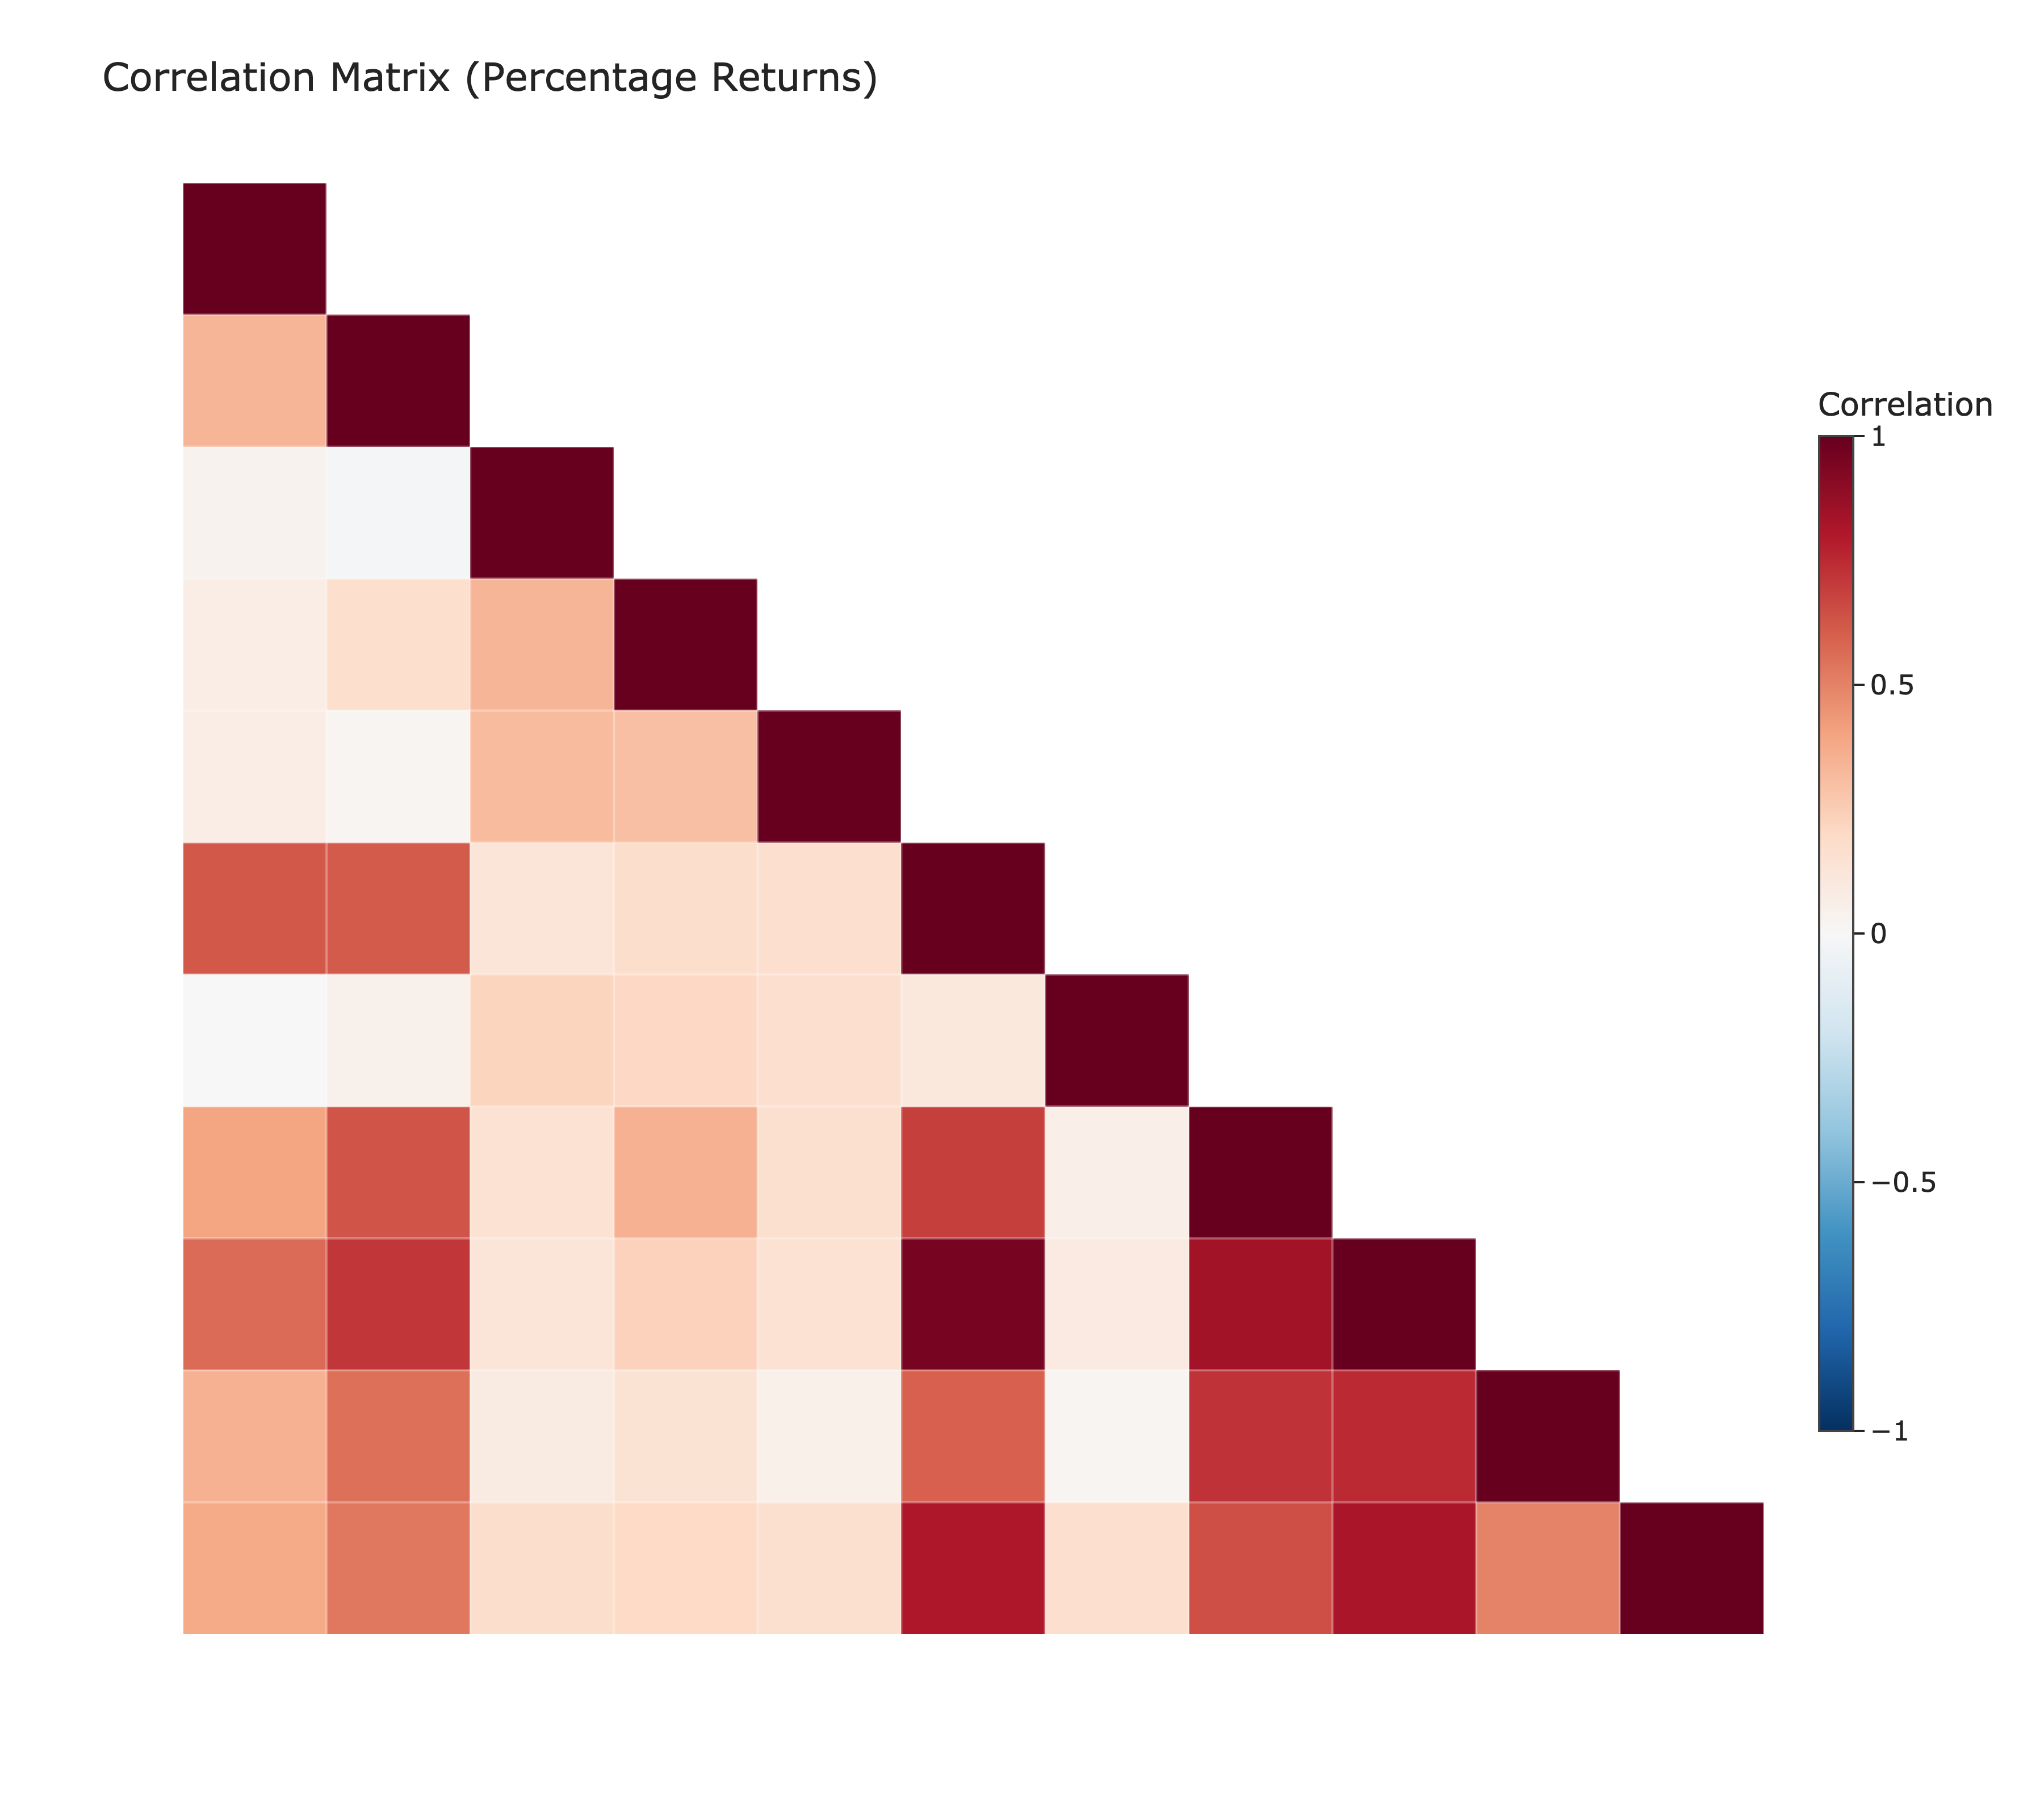

In [7]:
pv.plot_correlation_matrix(portfolio_matrix, interactive=False)

In [8]:
portfolio_matrix.tail()

,AAPL,EWJ,JNJ,NVS,PG,SPY,UNH,VGK,VT,VWO,XLI
Date,,,,,,,,,,,
2024-12-24,12864.334106,2636.656494,7120.828247,2844.668884,6629.697876,47818.359375,20015.764160,3764.303513,14249.017639,2675.722961,-4000.299225
2024-12-26,12905.186462,2667.209167,7107.645416,2846.115189,6677.575073,47821.547852,20215.485840,3774.314804,14265.683899,2669.148788,-4003.280640
2024-12-27,12734.294128,2687.445679,7081.769562,2845.825882,6652.851562,47318.149414,20169.609375,3761.947861,14153.787231,2659.586105,-3973.463287
2024-12-30,12565.393066,2664.828796,6998.281860,2815.166473,6557.098389,46778.173828,20082.996826,3737.213516,14016.892090,2636.277466,-3933.508301
2024-12-31,12476.708221,2662.447815,7060.775757,2814.587860,6579.074707,46607.993164,20006.270752,3737.802658,13984.751587,2632.093735,-3928.737488


In [9]:
portfolio_returns.tail()

,AAPL,EWJ,JNJ,NVS,PG,SPY,UNH,VGK,VT,VWO,XLI
Date,,,,,,,,,,,
2024-12-24,0.011478,-0.000602,0.003993,-0.001016,0.004937,0.011115,-0.000474,0.005506,0.007915,0.004037,0.007812
2024-12-26,0.003176,0.011588,-0.001851,0.000508,0.007222,0.000067,0.009978,0.002660,0.001170,-0.002457,0.000745
2024-12-27,-0.013242,0.007587,-0.003641,-0.000102,-0.003702,-0.010527,-0.002269,-0.003277,-0.007844,-0.003583,-0.007448
2024-12-30,-0.013263,-0.008416,-0.011789,-0.010773,-0.014393,-0.011412,-0.004294,-0.006575,-0.009672,-0.008764,-0.010055
2024-12-31,-0.007058,-0.000893,0.008930,-0.000206,0.003352,-0.003638,-0.003820,0.000158,-0.002293,-0.001587,-0.001213


If you want to **save the DataFrame shown above**, use:

```python
portfolio_returns.to_csv("portfolio_returns.csv")
```

If you want to **import your own CSV**, make sure the first column contains dates and use:

```python
df = pd.read_csv("your_file.csv", index_col=0, parse_dates=True)
```

This ensures:
- The first column becomes the date index
- Dates are properly parsed for the analysis

Note: You are responsible for data cleaning and pre-processing when using your own files. Our data-download functions will print warnings if there are issues, but they do not perform automatic cleaning.

---

### Sharpe Single Factor Model (CAPM)

We start with the most basic assumption: the **market variance is constant over time**. Later, we extend the model to incorporate **time-varying (conditional) volatility** using a GARCH-type specification.

For the Single Factor Model each asset’s return is modeled as:

$$
r_i = \alpha_i + \beta_i r_m + \varepsilon_i
$$

- $r_m$: market return (e.g., global index)
- $\beta_i$: sensitivity of asset $i$ to the market
- $\varepsilon_i$: idiosyncratic return (uncorrelated with $R_m$)

The asset variance is:

$$
\sigma_i^2 = \beta_i^2 \sigma_m^2 + \sigma_{\varepsilon_i}^2
$$

The **portfolio covariance matrix** is reconstructed as:

$$
\Sigma = \beta \beta^\top \cdot \sigma_m^2 + D
$$

- $\beta$: vector of asset betas  
- $\sigma_m^2$: variance of the market  
- $D$: diagonal matrix of residual variances

Once $\Sigma$ is estimated, portfolio volatility and risk measures follow from the delta-normal formula:
$$
\sigma_p = \sqrt{w^\top \Sigma w}, \quad 
\text{VaR}_{\alpha} = z_\alpha \, \sigma_p \, \quad 
\text{ES}_{\alpha} = \sigma_p \, \frac{\phi(z_\alpha)}{\alpha} \,
$$


In our case, we use the S&P 500 index as the market proxy. Even though the portfolio is globally diversified, the S&P 500 is a natural benchmark because of its central role in global equity markets and its strong influence on worldwide risk factors. It is the same index we used throughout the earlier univariate risk models.

In [39]:
# General parameter
confidence_level = 0.99

In [40]:
# Download the S&P 500 data from YF
sp_data = yf.download("^GSPC", start="2000-01-01", end="2025-01-01")

# Check for missing values in the entire DataFrame (including the new column)
print(sp_data.isnull().sum())

[*********************100%***********************]  1 of 1 completed

Price   Ticker
Close   ^GSPC     0
High    ^GSPC     0
Low     ^GSPC     0
Open    ^GSPC     0
Volume  ^GSPC     0
dtype: int64


In [41]:
# Compute log returns and remove the first NaN
sp_data["Log Returns"] = np.log(sp_data["Close"] / sp_data["Close"].shift(1))
sp_returns = sp_data["Log Returns"].dropna()

In [42]:
sp_returns.head()

Date
2000-01-04   -0.039099
2000-01-05    0.001920
2000-01-06    0.000955
2000-01-07    0.026730
2000-01-10    0.011128
Name: Log Returns, dtype: float64

In [43]:
# Take the existing VT returns and reindex it to the portfolio returns
benchmark = sp_returns.reindex(portfolio_returns.index).ffill() # <----- This should match the portfolio returns!

In [44]:
benchmark.head()

Date
2023-01-04    0.007511
2023-01-05   -0.011714
2023-01-06    0.022584
2023-01-09   -0.000768
2023-01-10    0.006954
Name: Log Returns, dtype: float64

In [45]:
# Check
print("Benchmark type:", type(benchmark))
print("Benchmark ndim:", benchmark.ndim)
print("Benchmark shape:", benchmark.shape)
print("Portfolio returns shape:", portfolio_returns.shape)
print("Index equal:", benchmark.index.equals(portfolio_returns.index))
print("Any NaNs in benchmark:", benchmark.isna().any())

Benchmark type: <class 'pandas.core.series.Series'>
Benchmark ndim: 1
Benchmark shape: (501,)
Portfolio returns shape: (501, 11)
Index equal: True
Any NaNs in benchmark: False


In [46]:
# VaR with single factor model
results_one_factor_df, portfolio_volatility = pv.single_factor_var( # <----- Notice how the volatility must be passed to ES
    returns=portfolio_returns,
    benchmark=benchmark,
    weights=weights,
    portfolio_value=portfolio_value_usd, # <----- Must pass the portfolio value! 
    confidence_level=confidence_level
)

# ES with single factor model
results_one_factor_df = pv.factor_models_es(
    result_data= results_one_factor_df,
    portfolio_volatility=portfolio_volatility, # <----- Must pass the volatility to ES!
    confidence_level = confidence_level
)


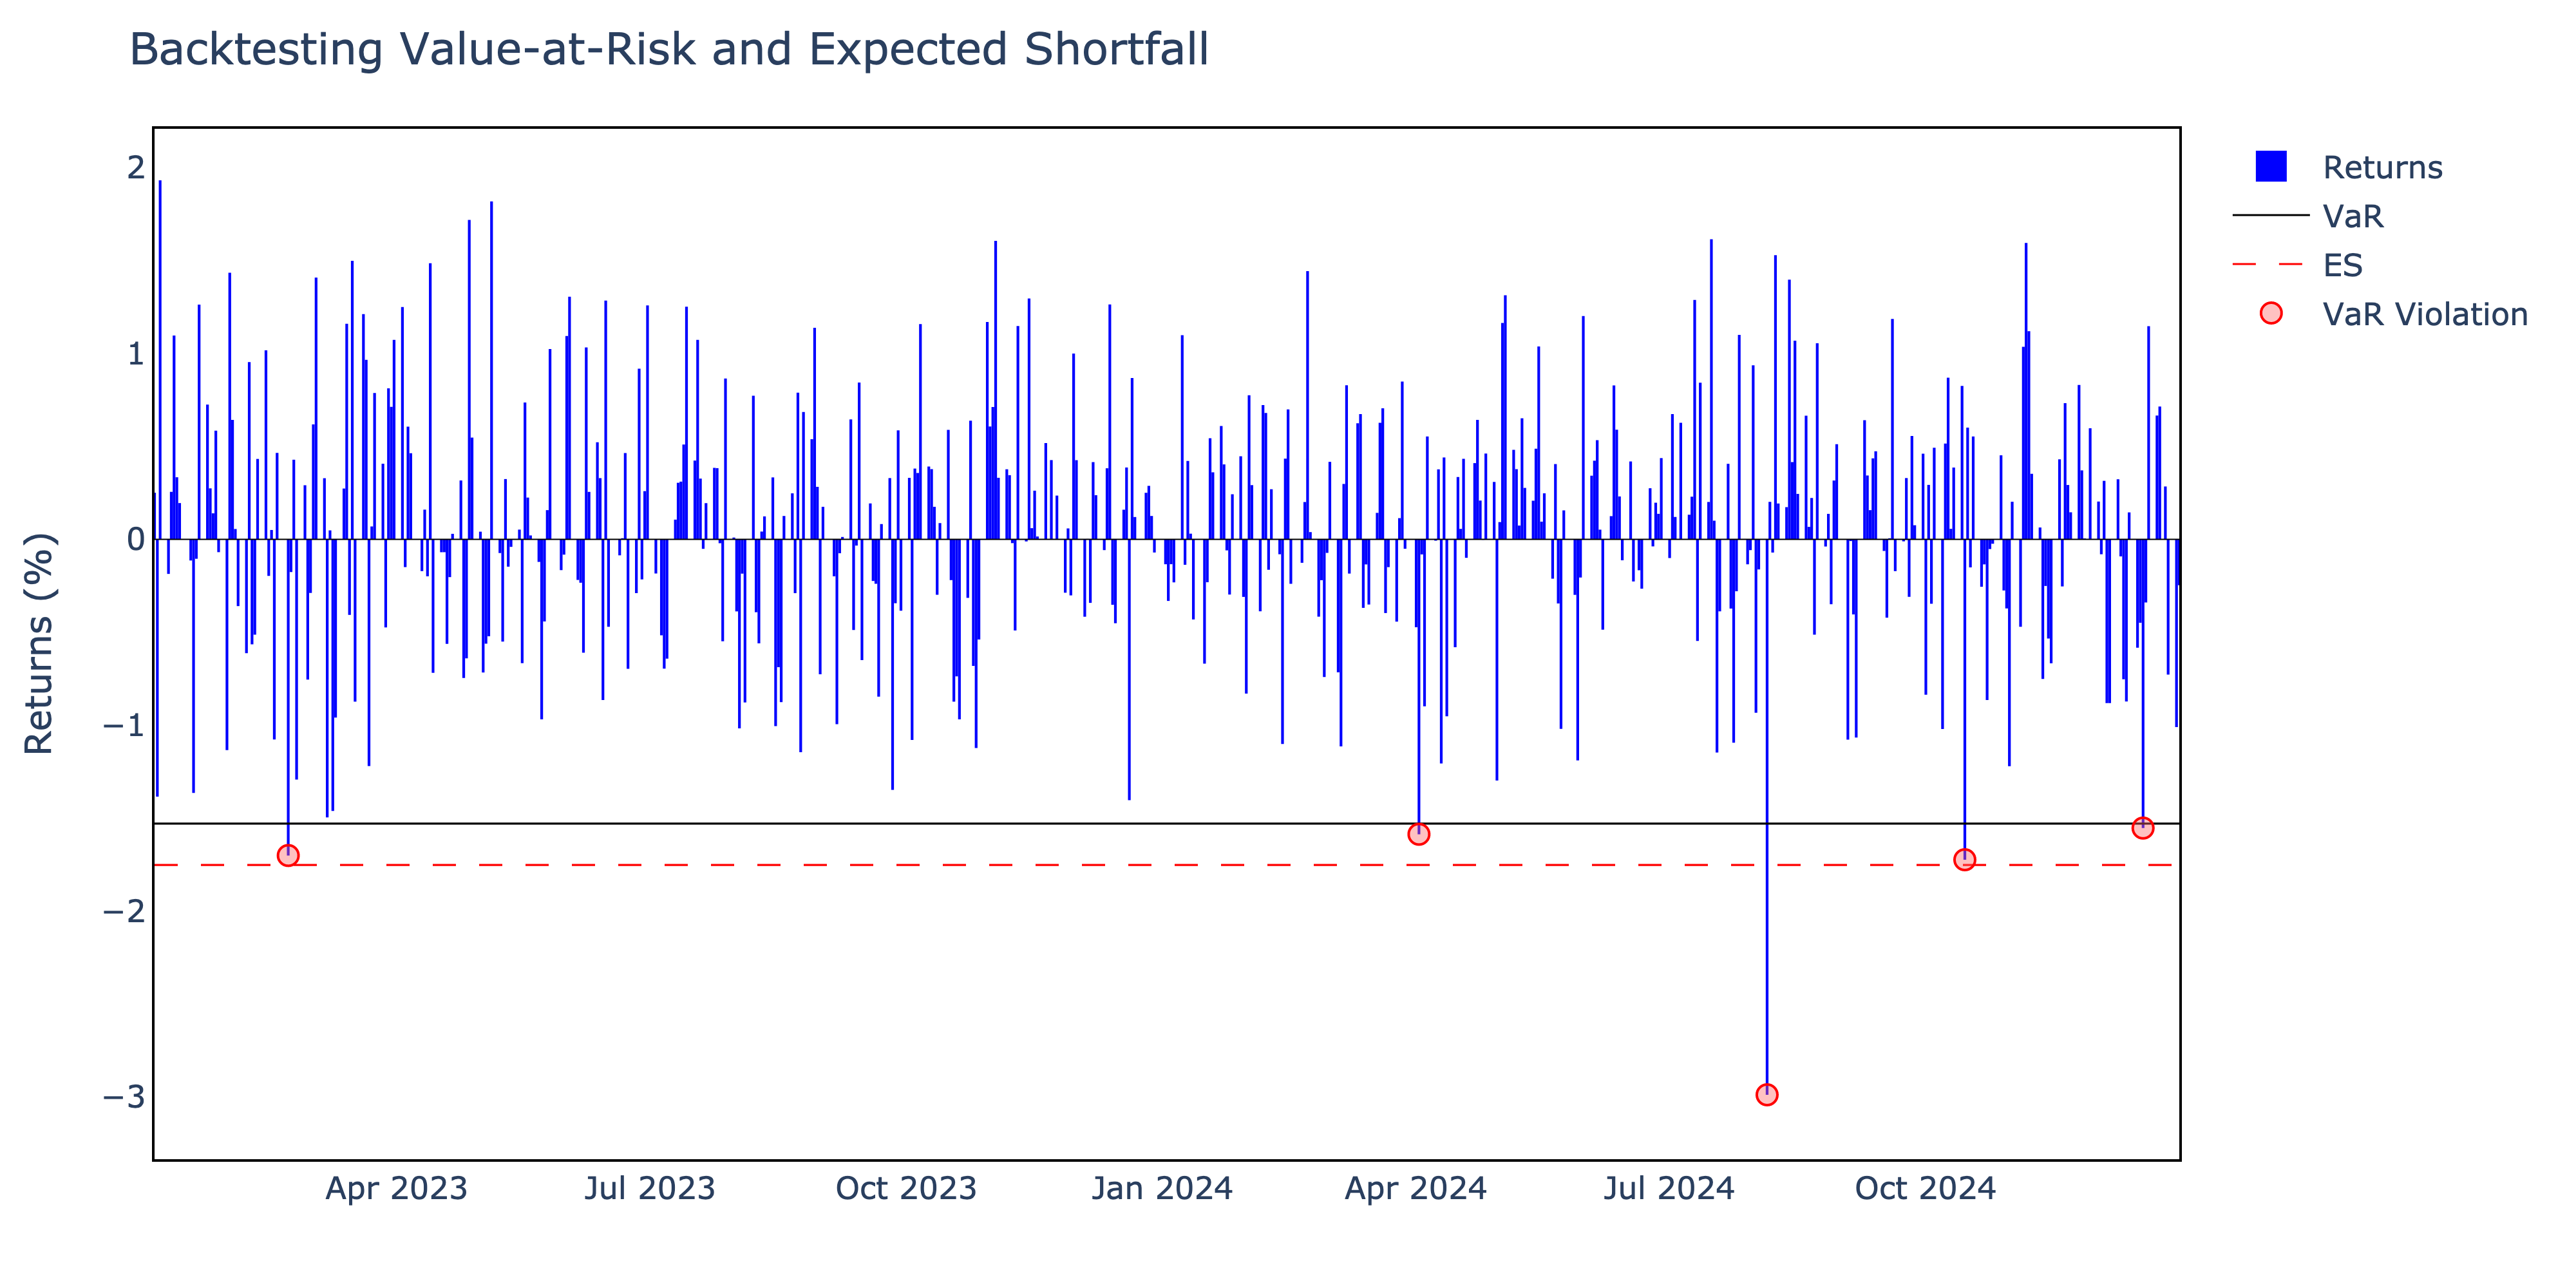

In [47]:
# Plot backtest
pv.plot_backtest(results_one_factor_df, interactive=False)

In [48]:
results_one_factor_df.head()

,Returns,VaR,VaR Violation,VaR_monetary,ES,ES_monetary
Date,,,,,,
2023-01-04,0.002508,0.015292,False,1752.947271,0.017519,2008.289494
2023-01-05,-0.013836,0.015292,False,1752.947271,0.017519,2008.289494
2023-01-06,0.019313,0.015292,False,1752.947271,0.017519,2008.289494
2023-01-09,-0.001859,0.015292,False,1752.947271,0.017519,2008.289494
2023-01-10,0.002556,0.015292,False,1752.947271,0.017519,2008.289494


#### Backtesting Single Factor Models

The model performed very well, passing all three backtesting tests — a strong initial result. However, with a much longer time series, the independence and joint tests would likely fail, highlighting the need to account for conditional volatility dynamics.

In [49]:
# Count violations
sf_violations, sf_violation_rate = pv.count_violations(results_one_factor_df)

# Kupiec Test (Unconditional Coverage)
sf_kupiec = pv.kupiec_test(
    total_violations=sf_violations,
    total_days=len(results_one_factor_df),
    confidence_level=confidence_level
)

# Christoffersen Test (Independence)
sf_christoffersen = pv.christoffersen_test(results_one_factor_df)

# Joint Test (Conditional Coverage)
sf_joint = pv.joint_lr_test(
    LR_uc=sf_kupiec["LR_uc"],
    LR_c=sf_christoffersen["LR_c"]
)

In [50]:
# Summary output
print(f"\n--- Single-Factor VaR Backtesting Summary ---")
print(f"Total Violations     : {sf_violations}")
print(f"Violation Rate       : {sf_violation_rate * 100:.2f}%\n")

print("Kupiec Test (UC):")
print(f"LR_uc               : {sf_kupiec['LR_uc']:.4f}")
print(f"p-value             : {sf_kupiec['p_value']:.4f}")
print(f"Reject Null (5%)    : {sf_kupiec['reject_null']}")

print("\nChristoffersen Test (Independence):")
print(f"LR_c                : {sf_christoffersen['LR_c']:.4f}")
print(f"p-value             : {sf_christoffersen['p_value']:.4f}")
print(f"Reject Null (5%)    : {sf_christoffersen['reject_null']}")

print("\nJoint Test (Conditional Coverage):")
print(f"LR_total            : {sf_joint['LR_total']:.4f}")
print(f"p-value             : {sf_joint['p_value']:.4f}")
print(f"Reject Null (5%)    : {sf_joint['reject_null']}")


--- Single-Factor VaR Backtesting Summary ---
Total Violations     : 5
Violation Rate       : 1.00%

Kupiec Test (UC):
LR_uc               : 0.0000
p-value             : 0.9964
Reject Null (5%)    : False

Christoffersen Test (Independence):
LR_c                : 0.1010
p-value             : 0.7506
Reject Null (5%)    : False

Joint Test (Conditional Coverage):
LR_total            : 0.1010
p-value             : 0.9507
Reject Null (5%)    : False


---

### Fama-French 3-Factor Model

We now extend the factor model by introducing the **Fama-French 3-Factor Model**, which captures more dimensions of systematic risk than the single-index CAPM.

Each asset’s excess return (above the risk-free rate) is modeled as:


$$
r_i - r_f = \alpha_i + \beta_{i,1} \cdot \text{Mkt-RF} + \beta_{i,2} \cdot \text{SMB} + \beta_{i,3} \cdot \text{HML} + \varepsilon_i,
$$

- $\text{SMB}$: size factor (small minus big)  
- $\text{HML}$: value factor (high minus low)  
- $\beta$ coefficients measure the asset’s sensitivity to each factor

The **portfolio covariance matrix** is constructed as:

$$
\Sigma = B \cdot \Sigma_f \cdot B^\top + D
$$

- $B$: matrix of asset betas 
- $\Sigma_f$: covariance matrix of factor returns  
- $D$: diagonal matrix of residual variances

Our implementation automatically downloads the Fama-French factor data, so no manual input is required. This allows for a smooth estimation of exposures and risk attribution using standard multifactor structure.


In [51]:
# Compute time-varying VaR using GARCH(1,1) on the FF factors
results_three_factor_df, portfolio_volatility_series = pv.fama_french_var(
    returns = portfolio_returns,
    weights = weights,
    portfolio_value = portfolio_value_usd,
    confidence_level = confidence_level,
    factors = None                     # <-- Optional: can preload factors if needed
)

# Estimate ES using time-varying volatility
results_three_factor_df = pv.factor_models_es(
    result_data = results_three_factor_df,
    portfolio_volatility = portfolio_volatility_series,
    confidence_level = confidence_level
)



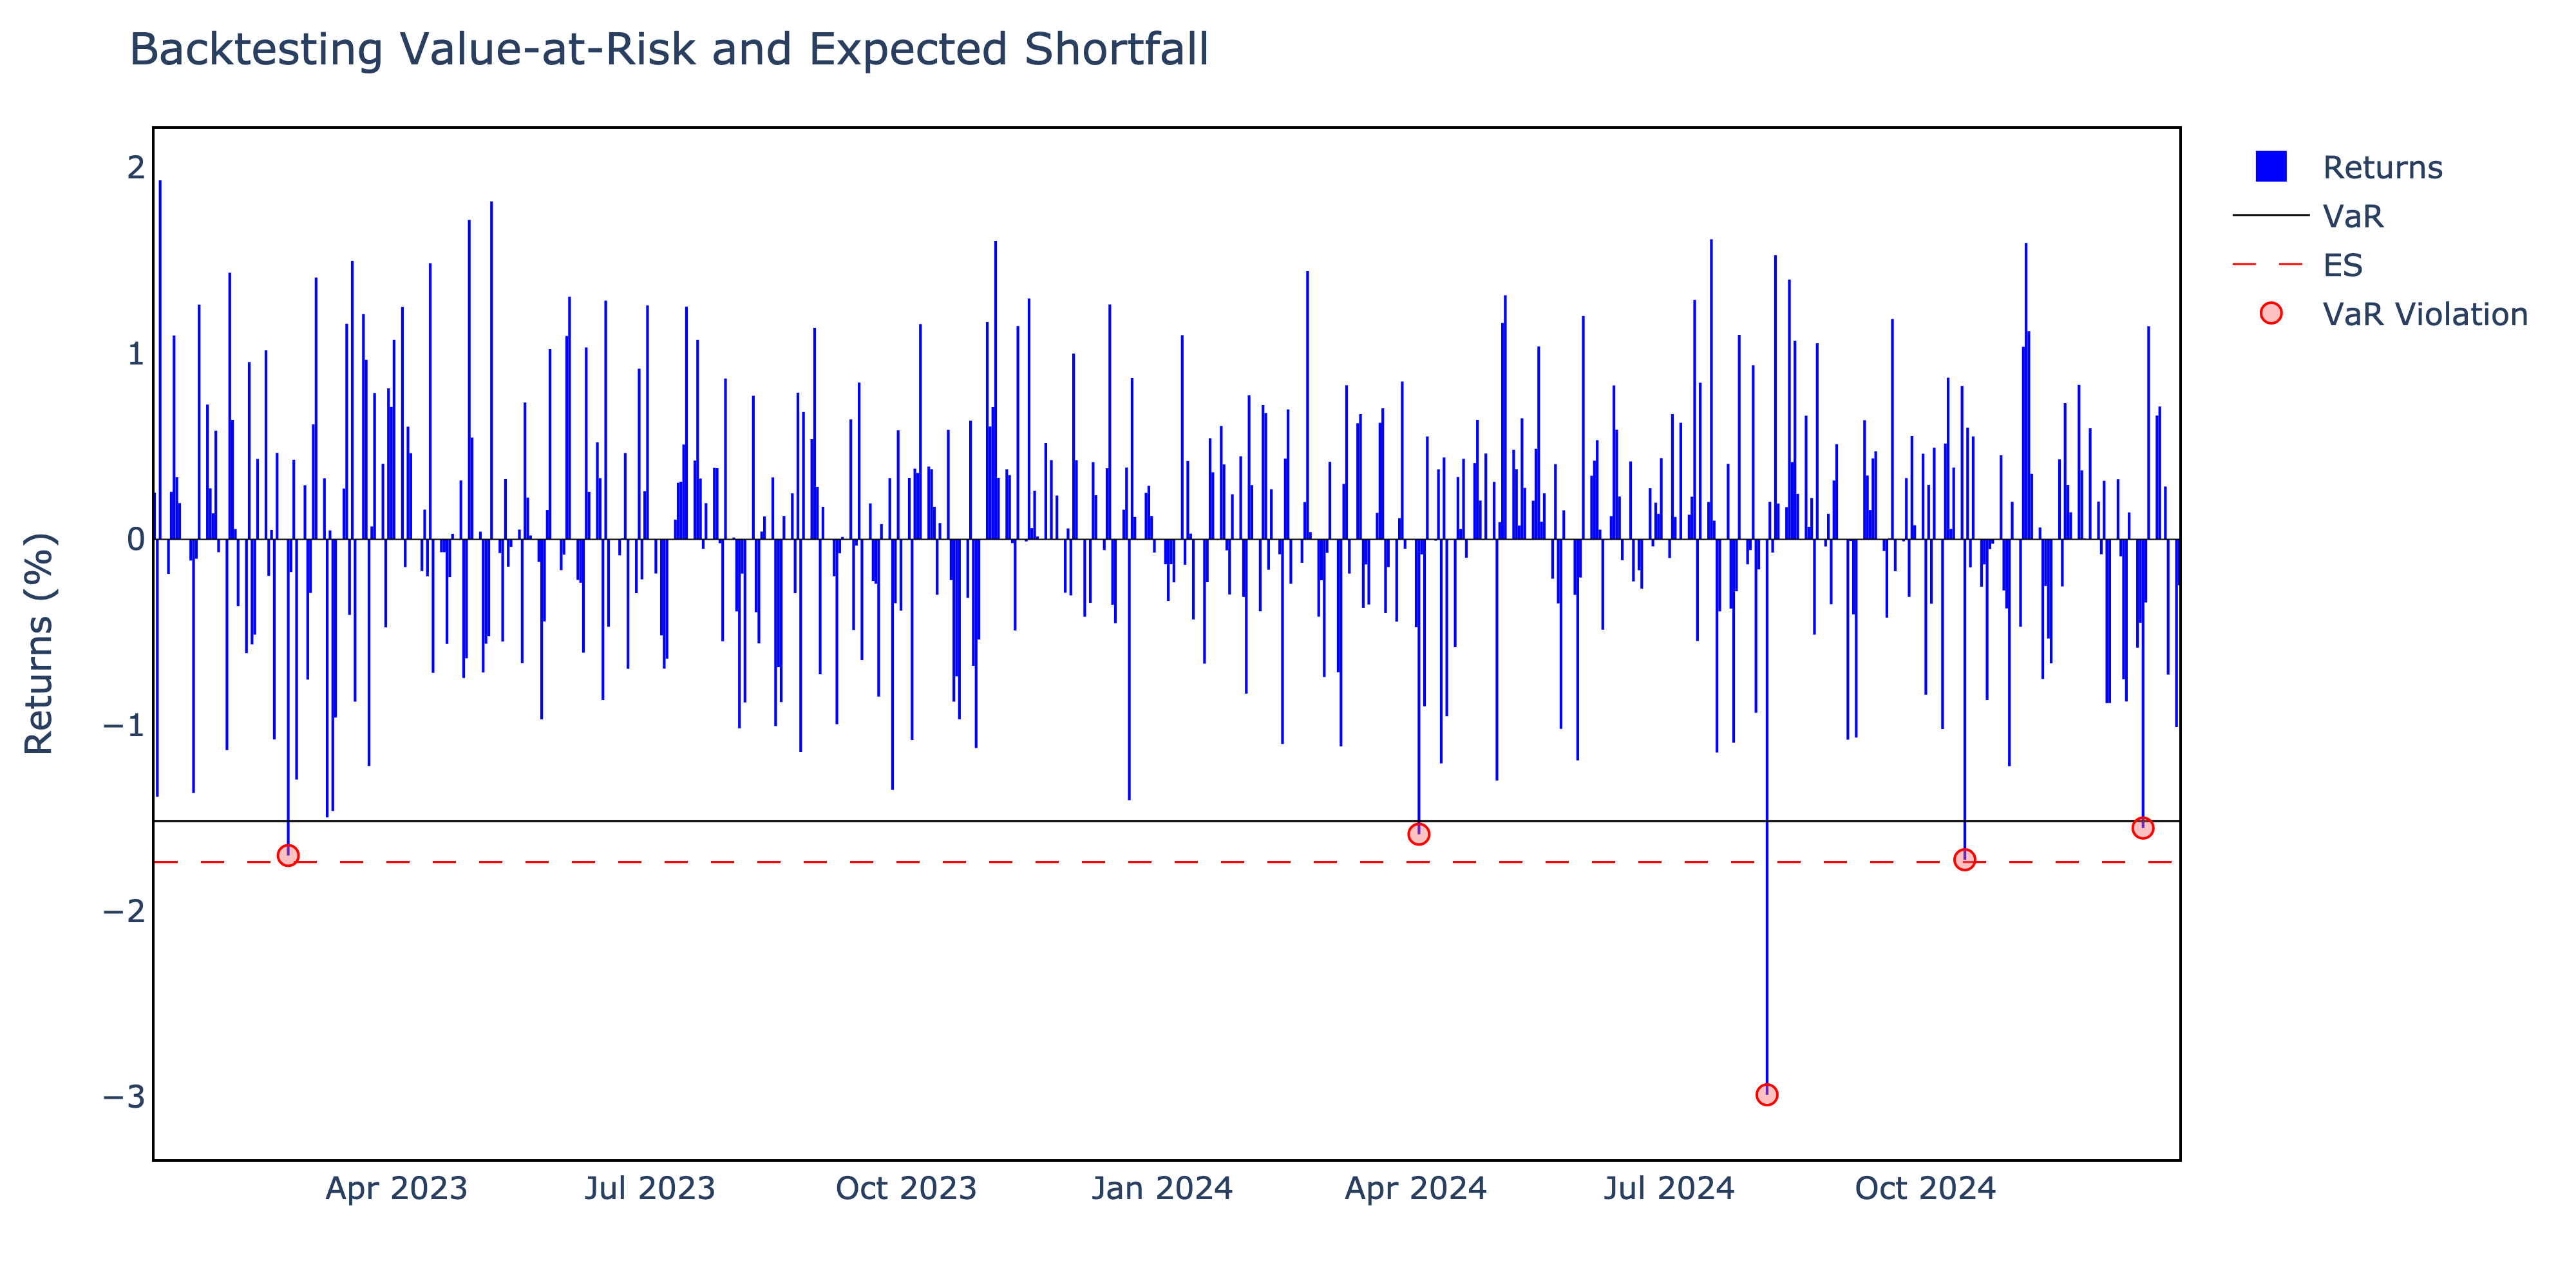

In [52]:
# Plot backtest
pv.plot_backtest(results_three_factor_df, interactive=False)

#### Backtesting 3 Factor Models

In [53]:
# Count VaR violations
ff3_static_violations, ff3_static_violation_rate = pv.count_violations(results_three_factor_df)

# Kupiec test (unconditional coverage)
ff3_static_kupiec = pv.kupiec_test(
    total_violations = ff3_static_violations,
    total_days = len(results_three_factor_df),
    confidence_level = confidence_level
)

# Christoffersen test (independence of violations)
ff3_static_christoffersen = pv.christoffersen_test(results_three_factor_df)

# Joint likelihood ratio test (conditional coverage)
ff3_static_joint = pv.joint_lr_test(
    LR_uc = ff3_static_kupiec["LR_uc"],
    LR_c  = ff3_static_christoffersen["LR_c"]
)

In [54]:
# Print summary
print(f"\n--- FF3 VaR Backtesting Summary (Static Volatility) ---")
print(f"Total Violations     : {ff3_static_violations}")
print(f"Violation Rate       : {ff3_static_violation_rate * 100:.2f}%\n")

print("Kupiec Test (UC):")
print(f"LR_uc               : {ff3_static_kupiec['LR_uc']:.4f}")
print(f"p-value             : {ff3_static_kupiec['p_value']:.4f}")
print(f"Reject Null (5%)    : {ff3_static_kupiec['reject_null']}")

print("\nChristoffersen Test (Independence):")
print(f"LR_c                : {ff3_static_christoffersen['LR_c']:.4f}")
print(f"p-value             : {ff3_static_christoffersen['p_value']:.4f}")
print(f"Reject Null (5%)    : {ff3_static_christoffersen['reject_null']}")

print("\nJoint Test (Conditional Coverage):")
print(f"LR_total            : {ff3_static_joint['LR_total']:.4f}")
print(f"p-value             : {ff3_static_joint['p_value']:.4f}")
print(f"Reject Null (5%)    : {ff3_static_joint['reject_null']}")


--- FF3 VaR Backtesting Summary (Static Volatility) ---
Total Violations     : 5
Violation Rate       : 1.00%

Kupiec Test (UC):
LR_uc               : 0.0000
p-value             : 0.9964
Reject Null (5%)    : False

Christoffersen Test (Independence):
LR_c                : 0.1010
p-value             : 0.7506
Reject Null (5%)    : False

Joint Test (Conditional Coverage):
LR_total            : 0.1010
p-value             : 0.9507
Reject Null (5%)    : False


---

### Adding Conditional Volatility (GARCH)

To capture volatility clustering and dynamic risk, we fit **GARCH-type models** on the factor returns — both for the market factor (Sharpe) and for all three factors (Fama-French):

$$
\sigma_{f,t}^2 = \omega + \alpha \cdot r_{t-1}^2 + \beta \cdot \sigma_{f,t-1}^2
$$

This yields **time-varying factor volatilities**, so that the portfolio volatility becomes:

$$
\sigma_{p,t} = \sqrt{w^\top \left(B \cdot \Sigma_{f,t} \cdot B^\top + D \right) w}
$$

- $\Sigma_{f,t}$: conditional covariance of factors at time $t$

The VaR and ES are then updated **daily**, using the corresponding $\sigma_{p,t}$.

This hybrid method combines **economic structure** (factor exposures) with **statistical realism** (time-varying risk), enabling responsive, interpretable, and scalable portfolio risk modeling.

In addition, the use of conditional volatility improves the quality of backtesting: it often leads to VaR estimates that pass the **Christoffersen independence test**, which checks whether violations occur randomly over time — a key property of a well-calibrated risk model.

#### Single Factor Model with GARCH Volatility

Specifically, we use an **APARCH(1,1)** model with **skewed t-distributed innovations**.

Compared to standard GARCH, APARCH adds two key features:  
- It models the **absolute value or power of returns**, allowing more flexible dynamics in volatility.  
- It captures **asymmetry**, meaning negative shocks can have a stronger impact on volatility than positive ones.

The use of a skewed t-distribution further accounts for **fat tails** and **return asymmetry**, making this model well-suited for financial time series with non-normal behavior.


In [55]:
# GARCH-Based Single-Factor VaR (APARCH with skew-t)
results_sf_garch_df, sf_garch_volatility = pv.single_factor_var(
    returns = portfolio_returns,
    benchmark = benchmark,
    weights = weights,
    portfolio_value = portfolio_value_usd,
    confidence_level = confidence_level,
    volatility_model = "APARCH",        # GARCH-type model
    p = 1,
    q = 1,
    distribution_volatility = "skewt"   # Skewed-t distribution
)

# Compute Expected Shortfall from time-varying volatility
results_sf_garch_df = pv.factor_models_es(
    result_data = results_sf_garch_df,
    portfolio_volatility = sf_garch_volatility,
    confidence_level = confidence_level
)


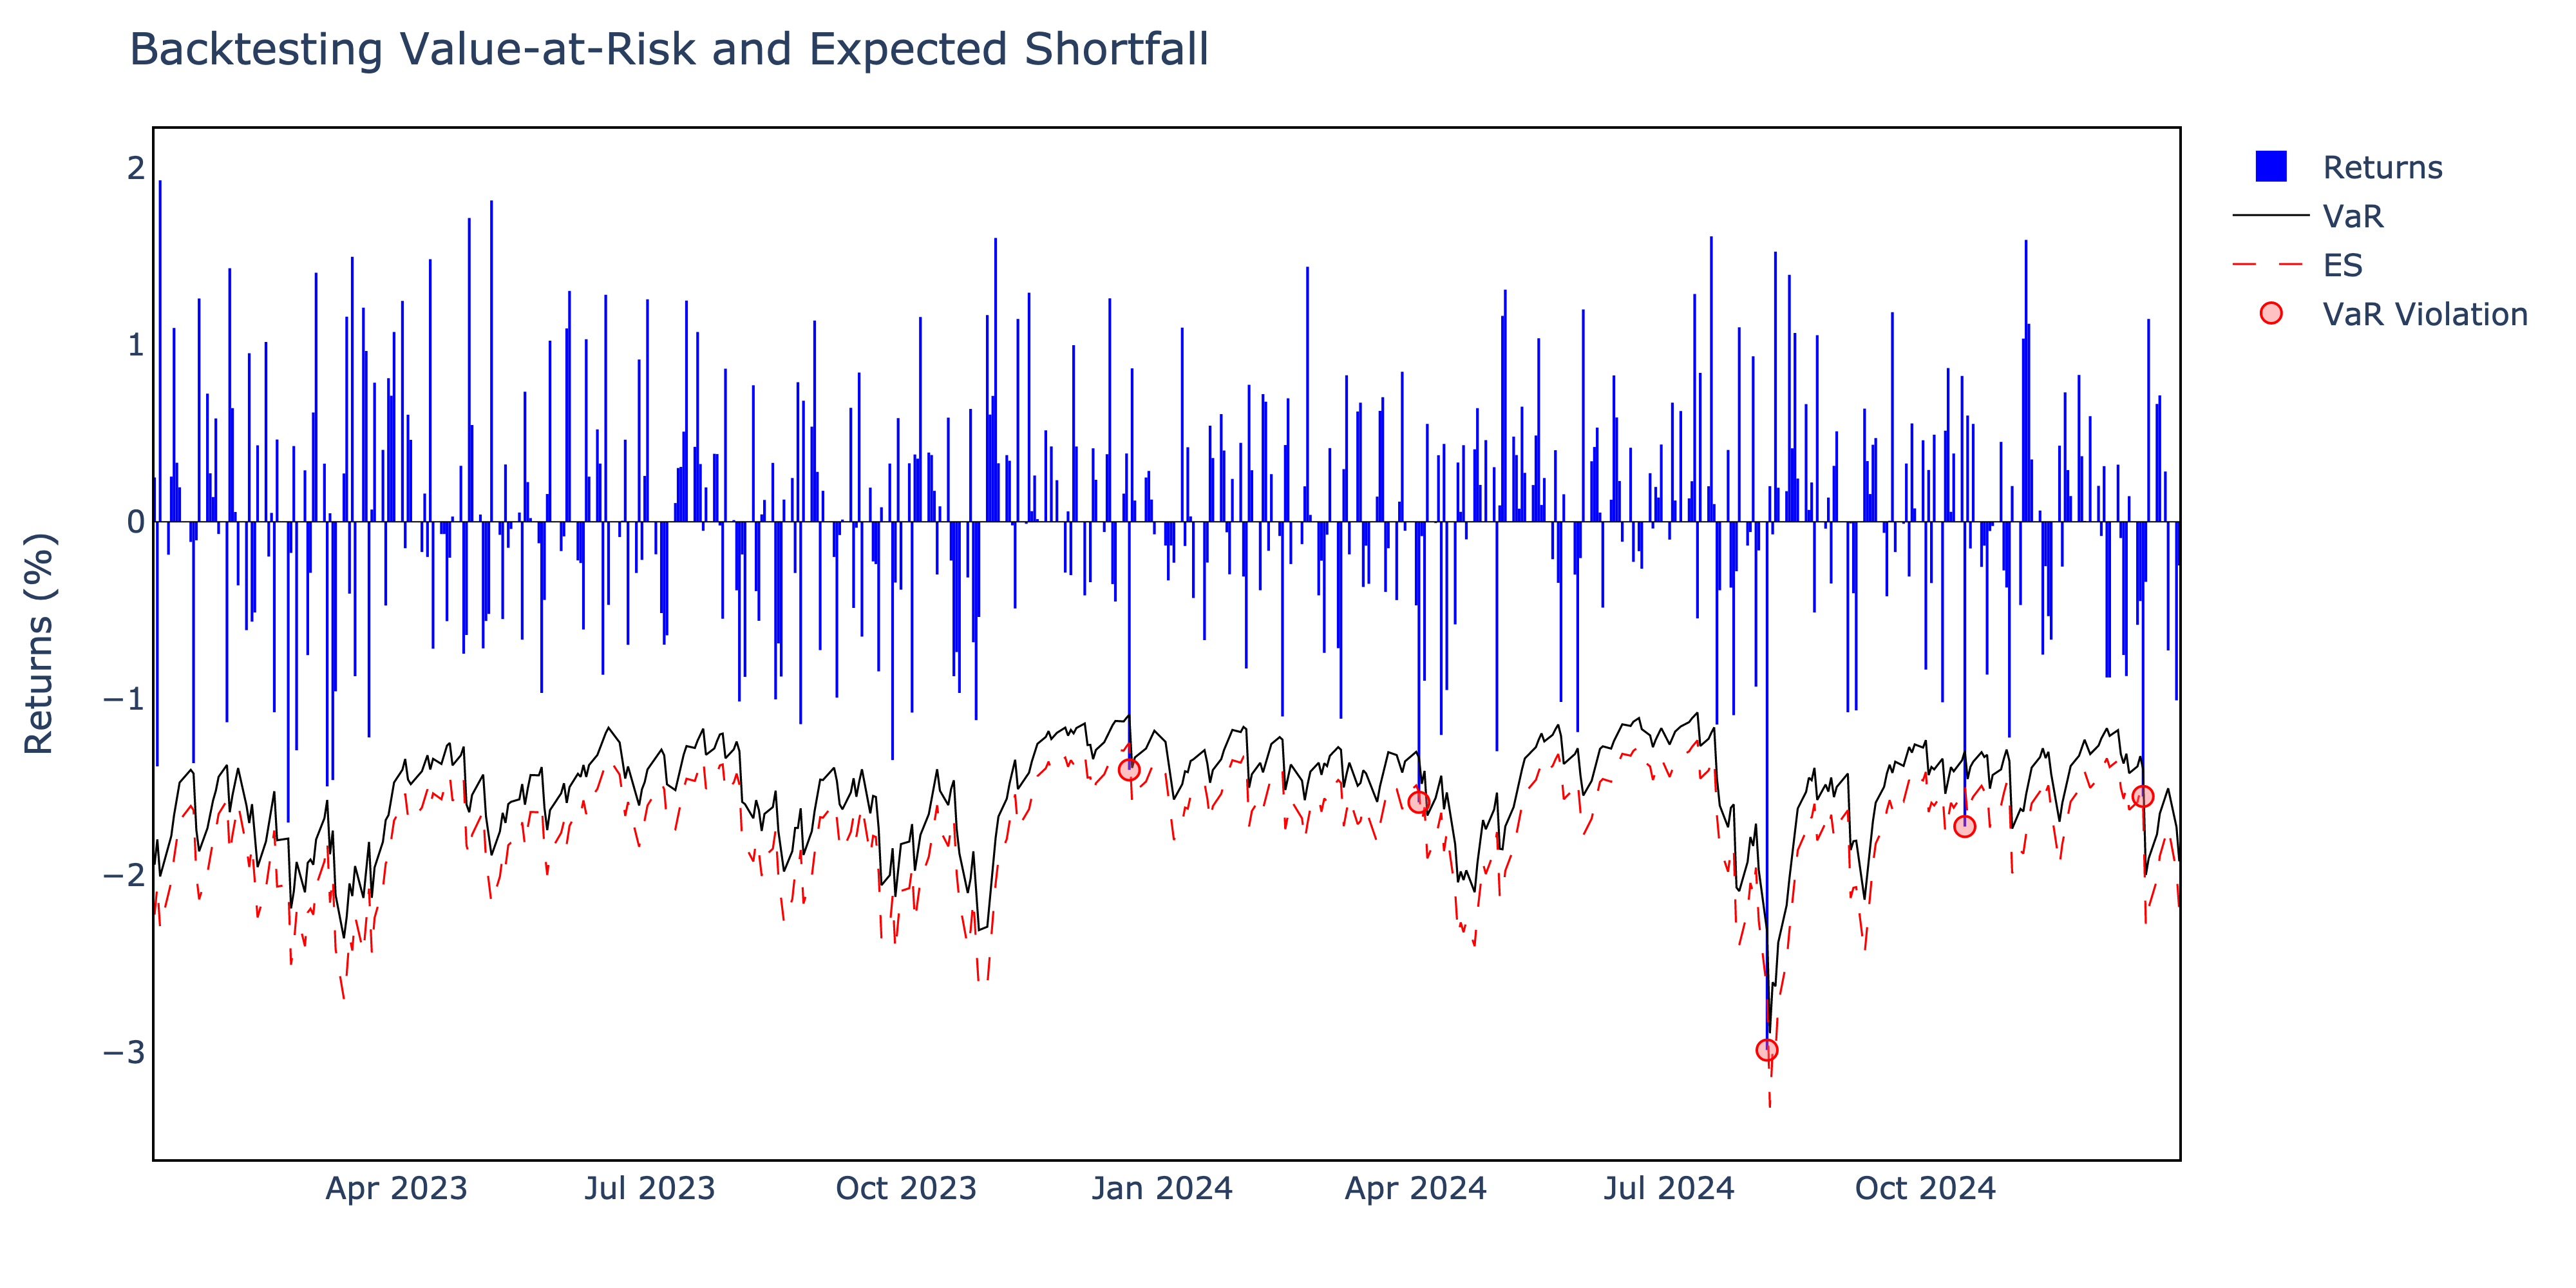

In [56]:
# Plot backtest
pv.plot_backtest(results_sf_garch_df, interactive=False)


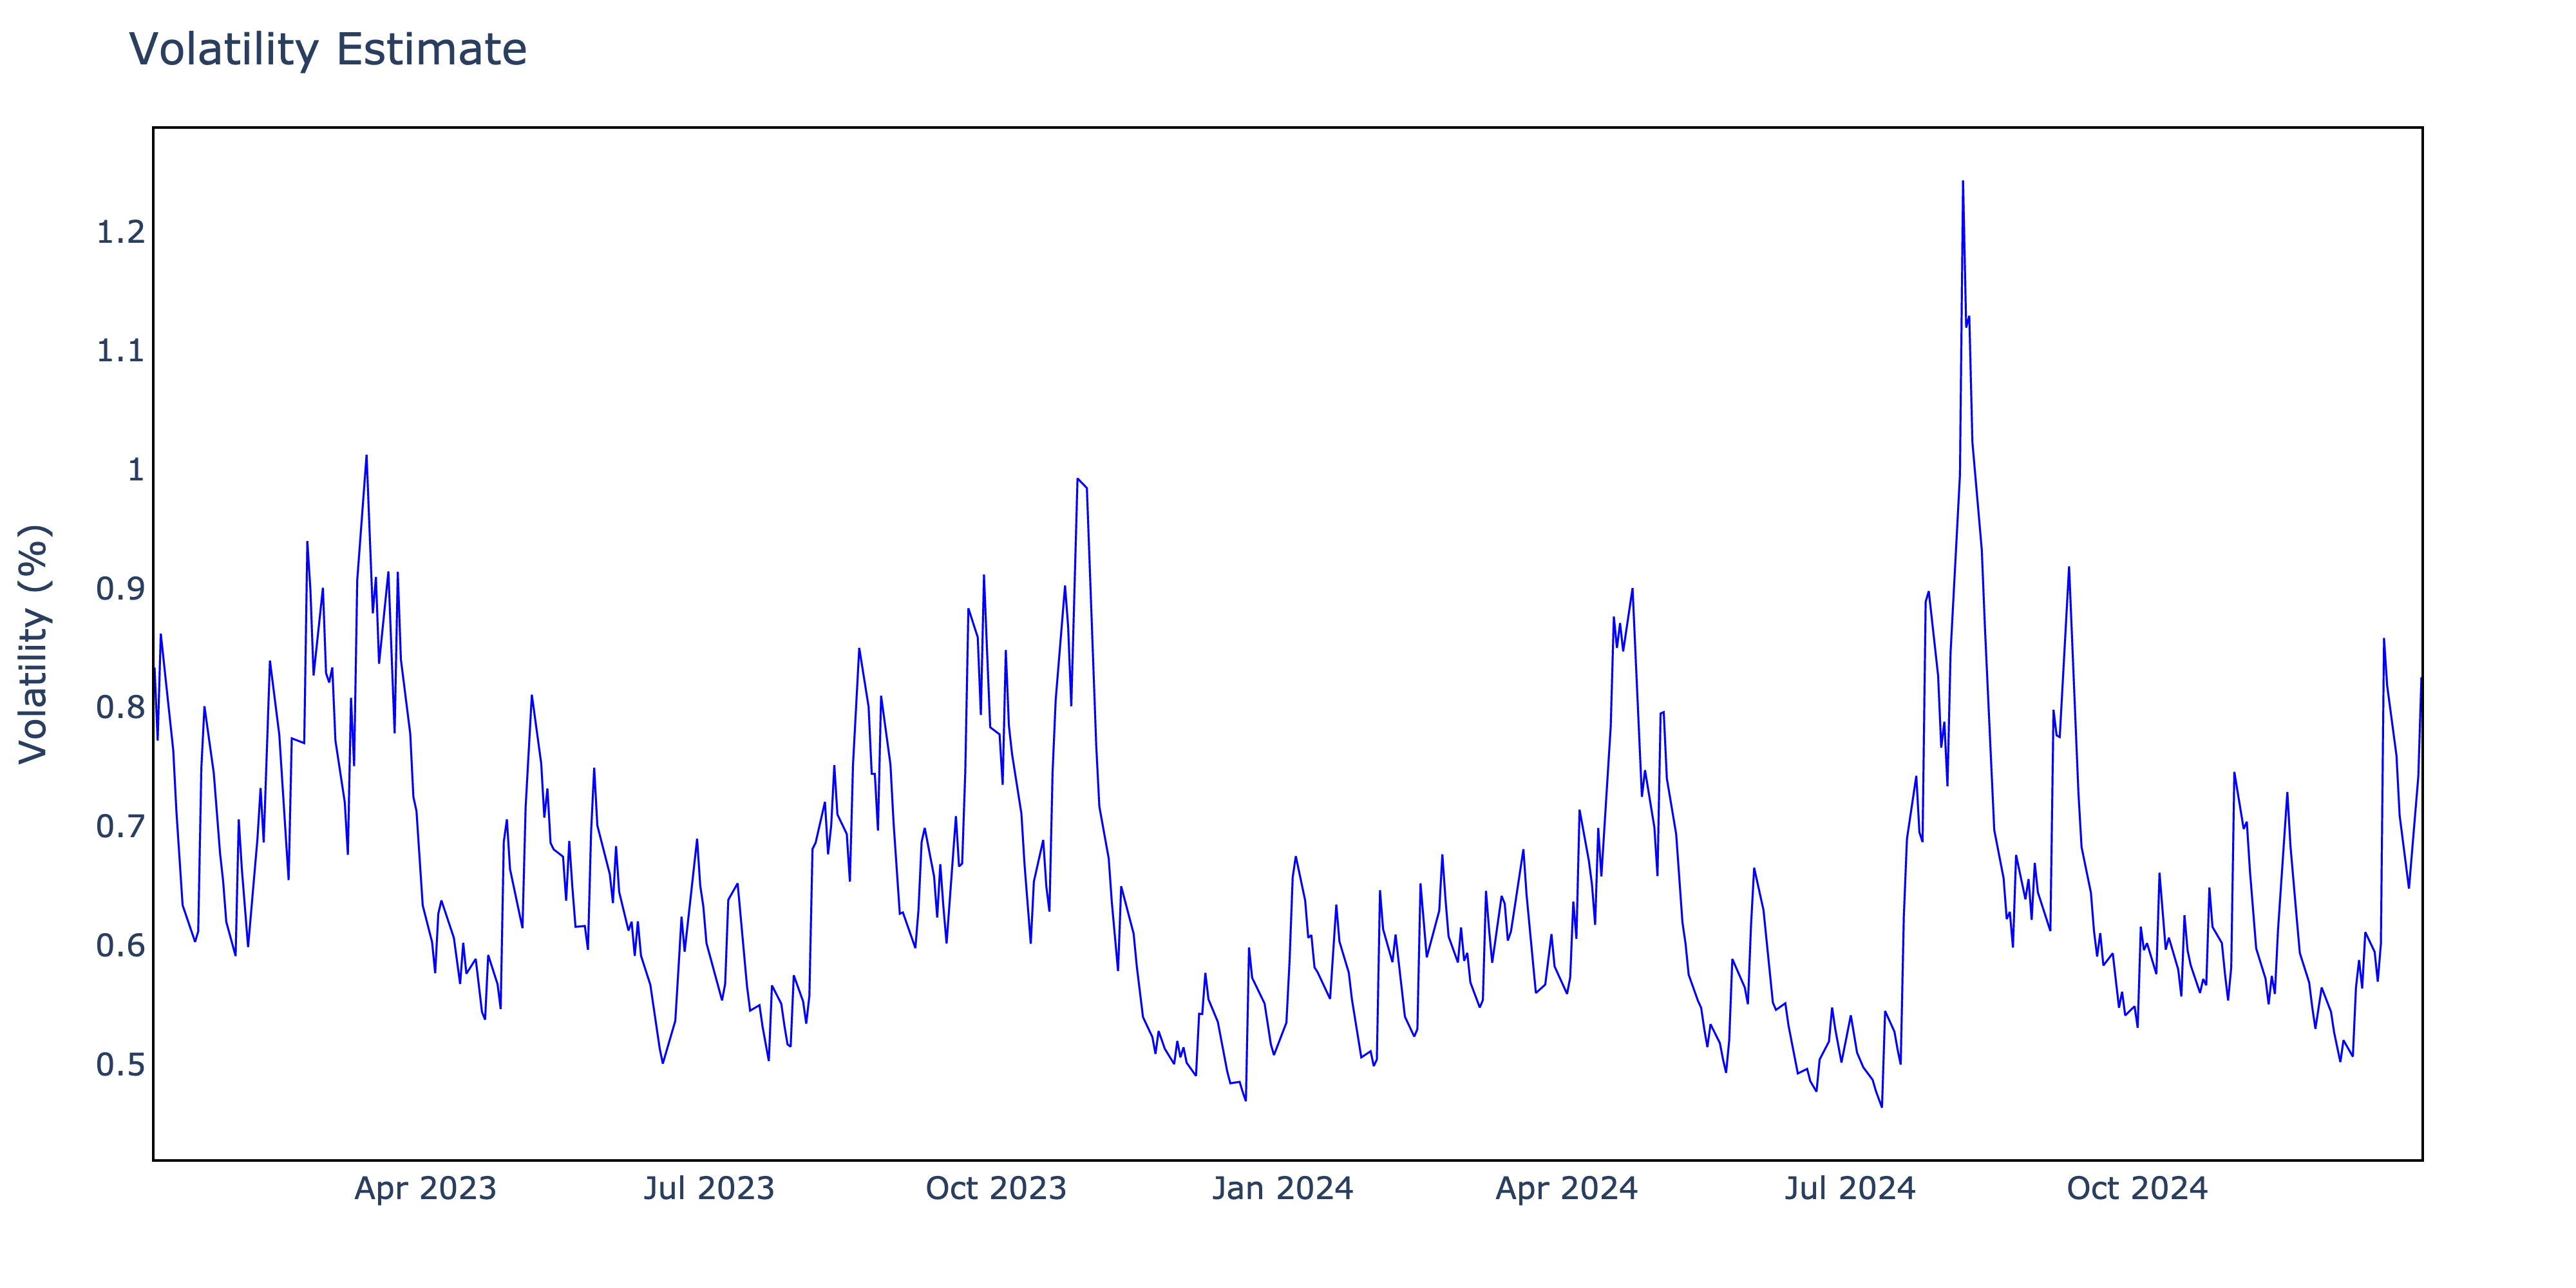

In [57]:
# Plot interactive volatility for a subset
pv.plot_volatility(sf_garch_volatility, interactive=False)

#### Backtesting Single Factor Model with Garch Volatility

In [58]:
# Count VaR violations
sf_garch_violations, sf_garch_violation_rate = pv.count_violations(results_sf_garch_df)

# Kupiec test (unconditional coverage)
sf_garch_kupiec = pv.kupiec_test(
    total_violations = sf_garch_violations,
    total_days = len(results_sf_garch_df),
    confidence_level = confidence_level
)

# Christoffersen test (independence)
sf_garch_christoffersen = pv.christoffersen_test(results_sf_garch_df)

# Joint likelihood ratio test
sf_garch_joint = pv.joint_lr_test(
    LR_uc = sf_garch_kupiec["LR_uc"],
    LR_c  = sf_garch_christoffersen["LR_c"]
)

In [59]:
# Print backtest summary
print(f"\n--- GARCH-Based Single-Factor VaR Backtesting Summary ---")
print(f"Total Violations     : {sf_garch_violations}")
print(f"Violation Rate       : {sf_garch_violation_rate * 100:.2f}%\n")

print("Kupiec Test (UC):")
print(f"LR_uc               : {sf_garch_kupiec['LR_uc']:.4f}")
print(f"p-value             : {sf_garch_kupiec['p_value']:.4f}")
print(f"Reject Null (5%)    : {sf_garch_kupiec['reject_null']}")

print("\nChristoffersen Test (Independence):")
print(f"LR_c                : {sf_garch_christoffersen['LR_c']:.4f}")
print(f"p-value             : {sf_garch_christoffersen['p_value']:.4f}")
print(f"Reject Null (5%)    : {sf_garch_christoffersen['reject_null']}")

print("\nJoint Test (Conditional Coverage):")
print(f"LR_total            : {sf_garch_joint['LR_total']:.4f}")
print(f"p-value             : {sf_garch_joint['p_value']:.4f}")
print(f"Reject Null (5%)    : {sf_garch_joint['reject_null']}")


--- GARCH-Based Single-Factor VaR Backtesting Summary ---
Total Violations     : 5
Violation Rate       : 1.00%

Kupiec Test (UC):
LR_uc               : 0.0000
p-value             : 0.9964
Reject Null (5%)    : False

Christoffersen Test (Independence):
LR_c                : 0.1010
p-value             : 0.7506
Reject Null (5%)    : False

Joint Test (Conditional Coverage):
LR_total            : 0.1010
p-value             : 0.9507
Reject Null (5%)    : False


#### Fama-French 3-Factor Model with GARCH Volatility

We apply the **same APARCH(1,1) with skewed t innovations** to each factor to capture conditional volatility.

In [60]:
# GARCH-Based Fama-French 3-Factor VaR (APARCH with skew-t)
results_ff3_garch_df, ff3_garch_volatility = pv.fama_french_var(
    returns = portfolio_returns,
    weights = weights,
    portfolio_value = portfolio_value_usd,
    confidence_level = confidence_level,
    volatility_model = "APARCH",        # GARCH-type model
    p = 1,
    q = 1,
    distribution_volatility = "skewt",  # Skewed-t distribution
    factors = None                      # Will auto-load FF3 if not provided
)

# Compute Expected Shortfall from time-varying volatility
results_ff3_garch_df = pv.factor_models_es(
    result_data = results_ff3_garch_df,
    portfolio_volatility = ff3_garch_volatility,
    confidence_level = confidence_level
)


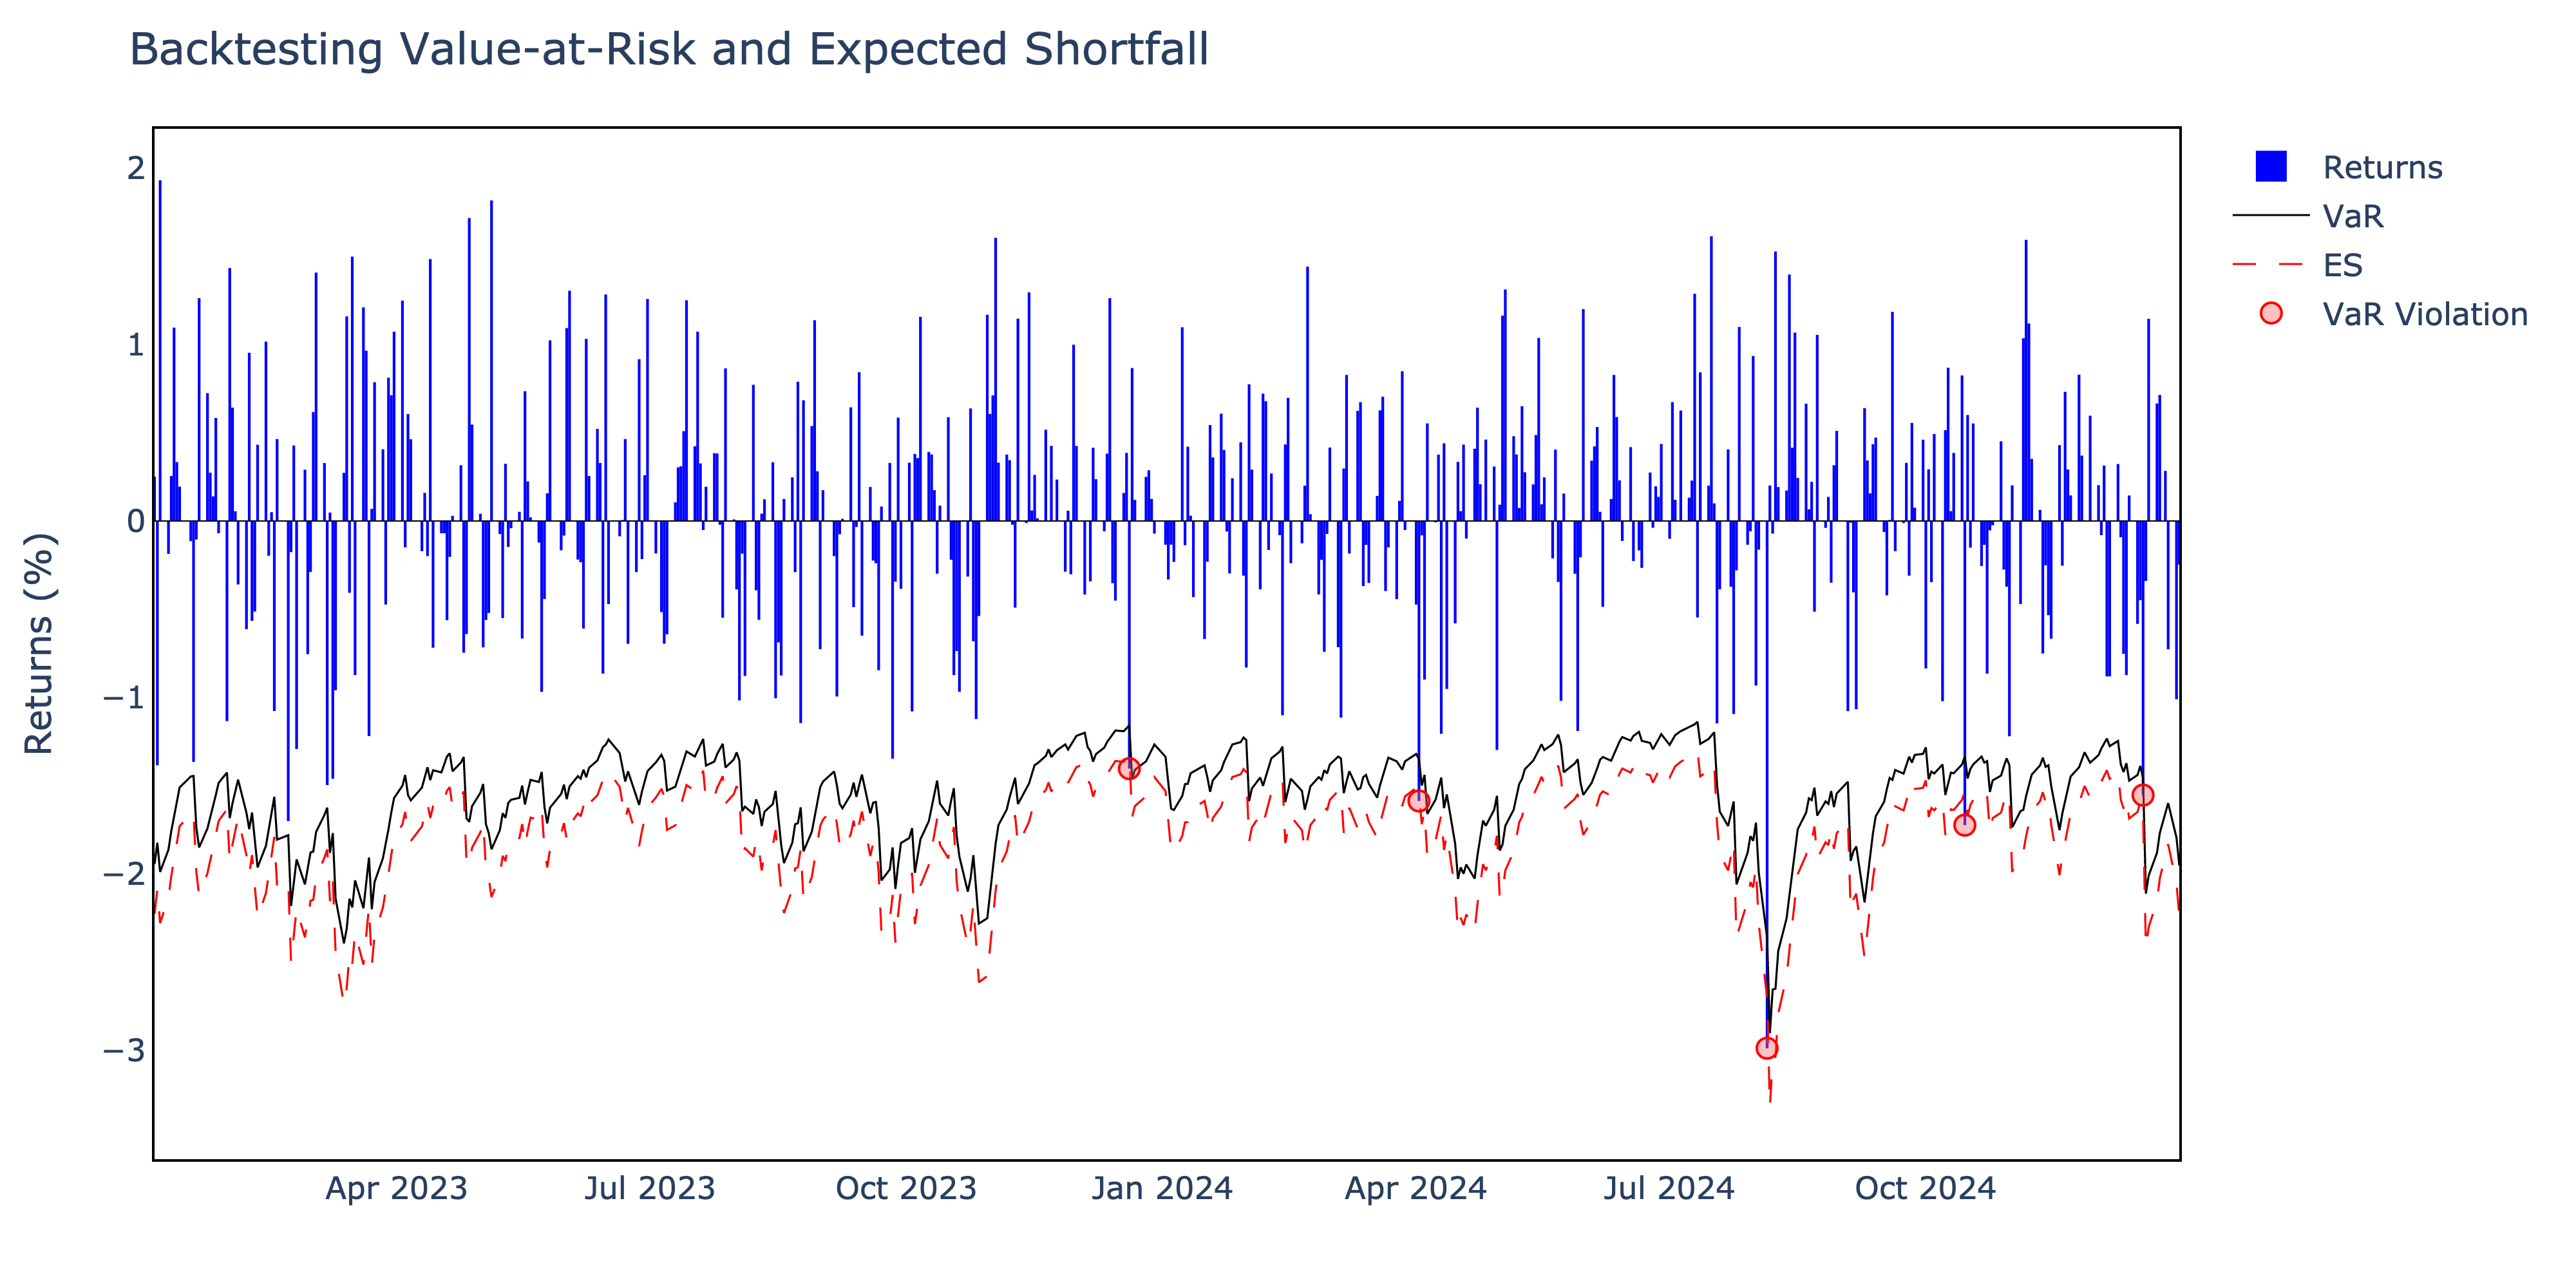

In [61]:
# Plot backtest
pv.plot_backtest(results_ff3_garch_df, interactive=False)


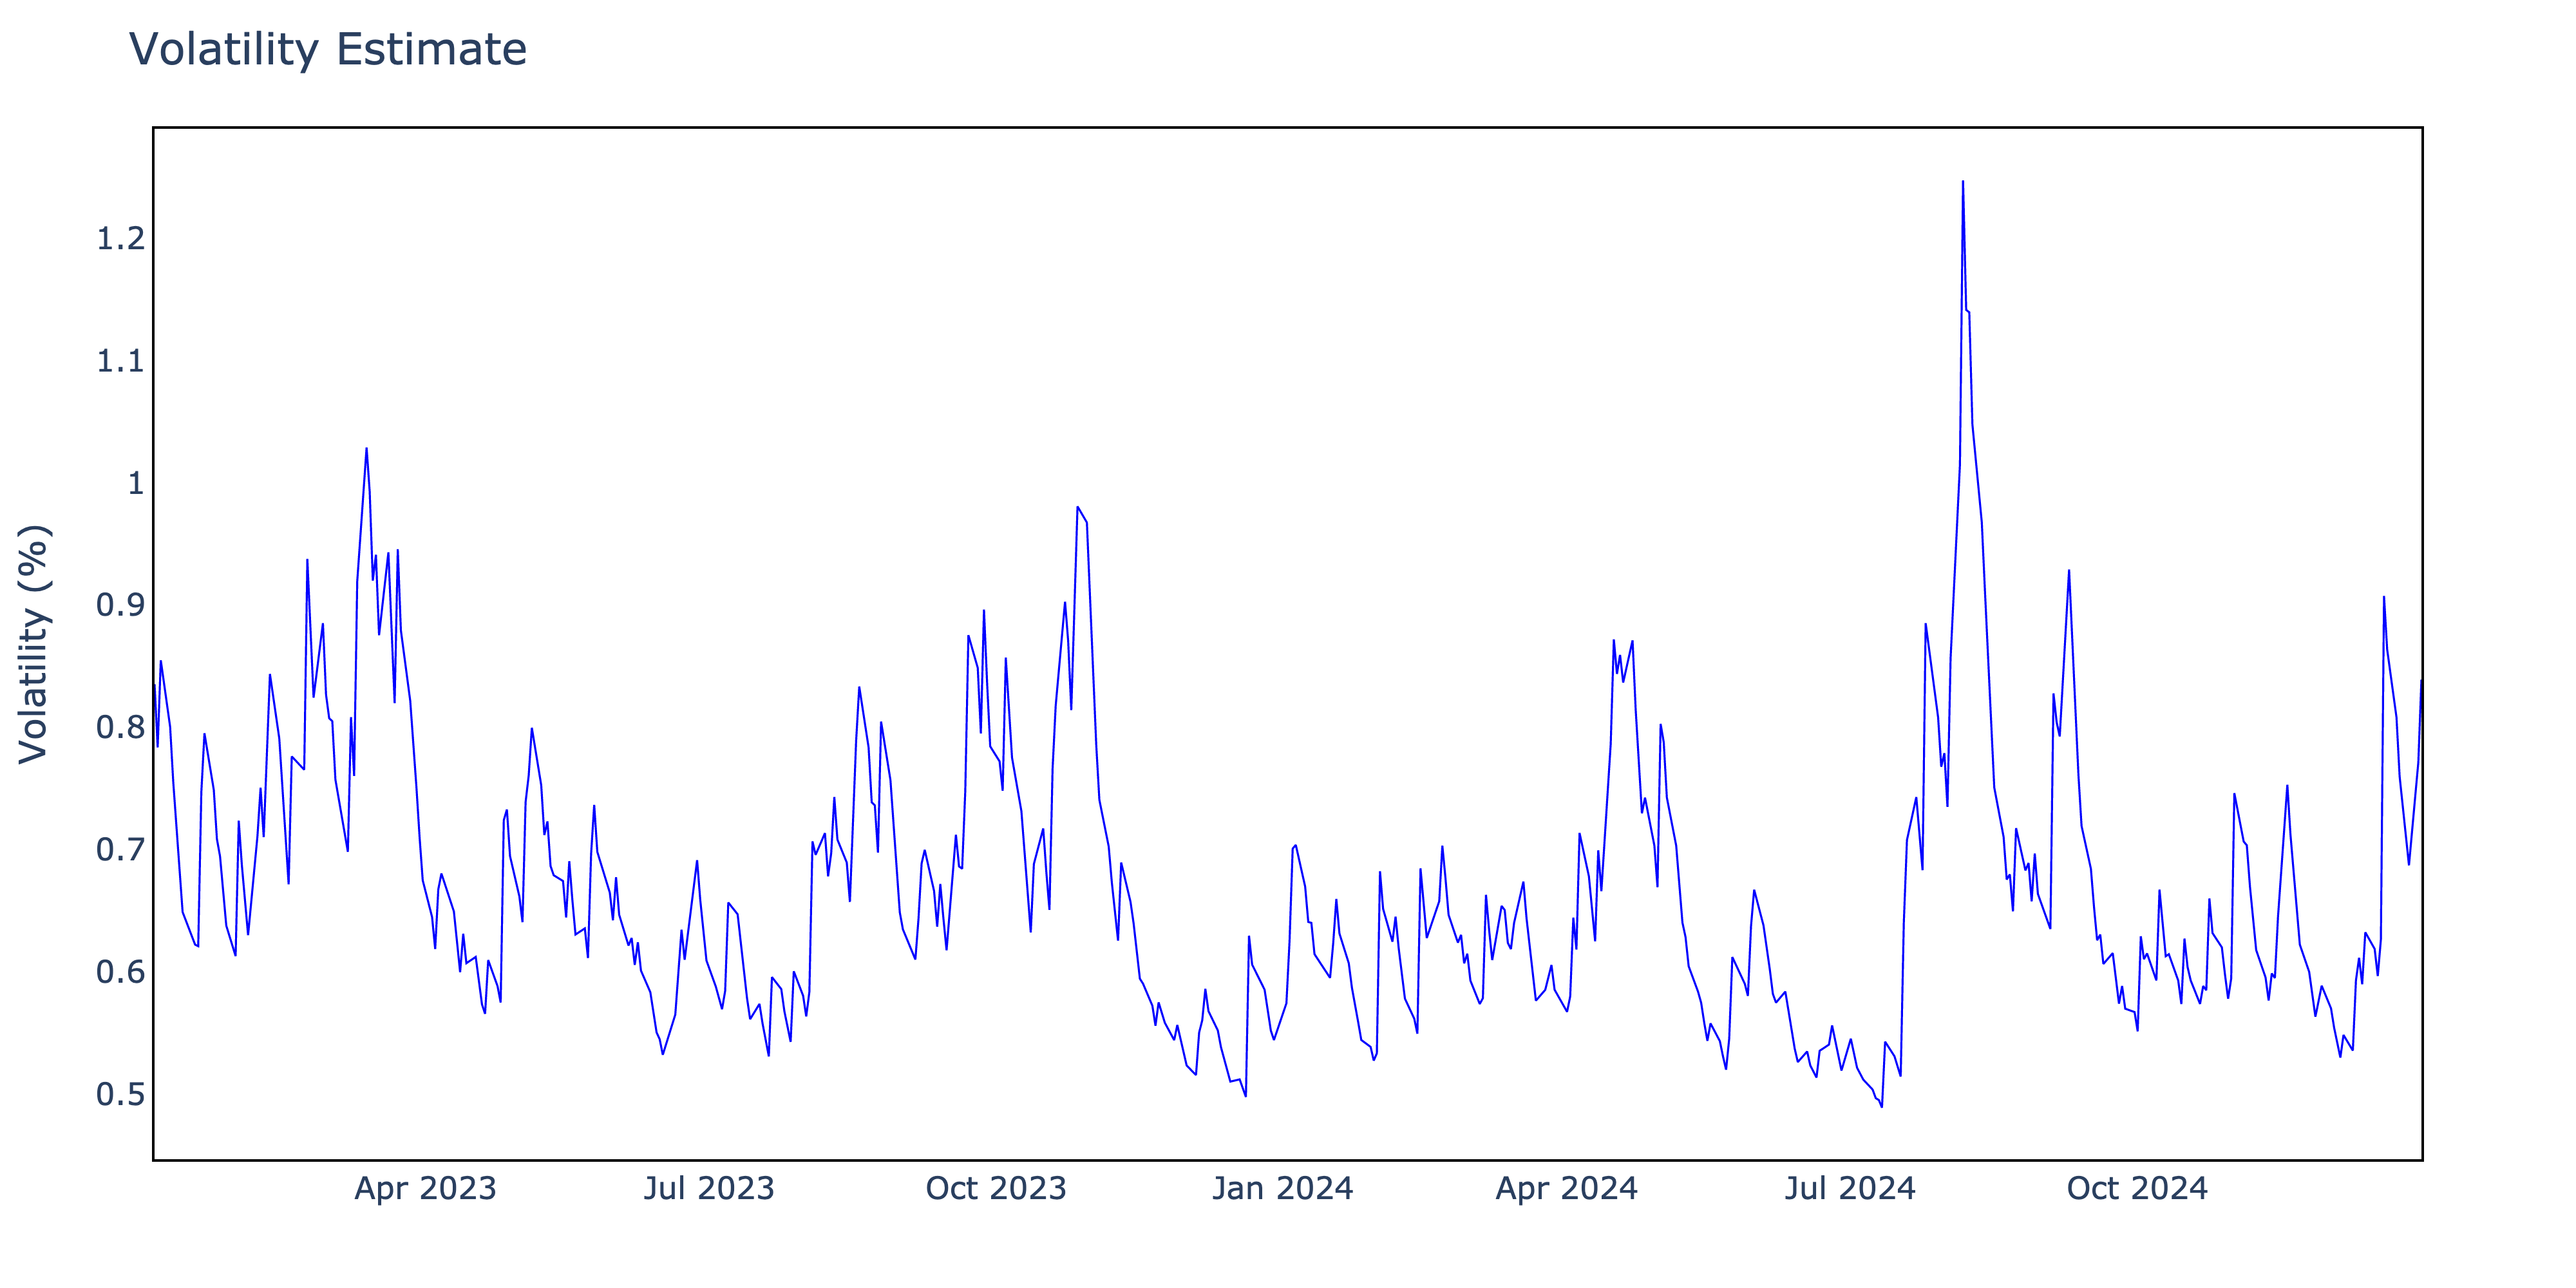

In [62]:
# Plot interactive volatility for a subset
pv.plot_volatility(ff3_garch_volatility, interactive=False)

#### Backtesting Fama-French 3-Factor Model with Garch Volatility

In [63]:
# Count VaR violations
ff3_garch_violations, ff3_garch_violation_rate = pv.count_violations(results_ff3_garch_df)

# Kupiec test (unconditional coverage)
ff3_garch_kupiec = pv.kupiec_test(
    total_violations = ff3_garch_violations,
    total_days = len(results_ff3_garch_df),
    confidence_level = confidence_level
)

# Christoffersen test (independence)
ff3_garch_christoffersen = pv.christoffersen_test(results_ff3_garch_df)

# Joint likelihood ratio test
ff3_garch_joint = pv.joint_lr_test(
    LR_uc = ff3_garch_kupiec["LR_uc"],
    LR_c  = ff3_garch_christoffersen["LR_c"]
)

In [64]:
# Print backtest summary
print(f"\n--- GARCH-Based FF3 VaR Backtesting Summary ---")
print(f"Total Violations     : {ff3_garch_violations}")
print(f"Violation Rate       : {ff3_garch_violation_rate * 100:.2f}%\n")

print("Kupiec Test (UC):")
print(f"LR_uc               : {ff3_garch_kupiec['LR_uc']:.4f}")
print(f"p-value             : {ff3_garch_kupiec['p_value']:.4f}")
print(f"Reject Null (5%)    : {ff3_garch_kupiec['reject_null']}")

print("\nChristoffersen Test (Independence):")
print(f"LR_c                : {ff3_garch_christoffersen['LR_c']:.4f}")
print(f"p-value             : {ff3_garch_christoffersen['p_value']:.4f}")
print(f"Reject Null (5%)    : {ff3_garch_christoffersen['reject_null']}")

print("\nJoint Test (Conditional Coverage):")
print(f"LR_total            : {ff3_garch_joint['LR_total']:.4f}")
print(f"p-value             : {ff3_garch_joint['p_value']:.4f}")
print(f"Reject Null (5%)    : {ff3_garch_joint['reject_null']}")


--- GARCH-Based FF3 VaR Backtesting Summary ---
Total Violations     : 5
Violation Rate       : 1.00%

Kupiec Test (UC):
LR_uc               : 0.0000
p-value             : 0.9964
Reject Null (5%)    : False

Christoffersen Test (Independence):
LR_c                : 0.1010
p-value             : 0.7506
Reject Null (5%)    : False

Joint Test (Conditional Coverage):
LR_total            : 0.1010
p-value             : 0.9507
Reject Null (5%)    : False


#### Portfolio Volatility Comparison

We now compare the portfolio volatility results from the two factor models—Sharpe and Fama-French—using an APARCH specification with skewed t-distributed innovations.

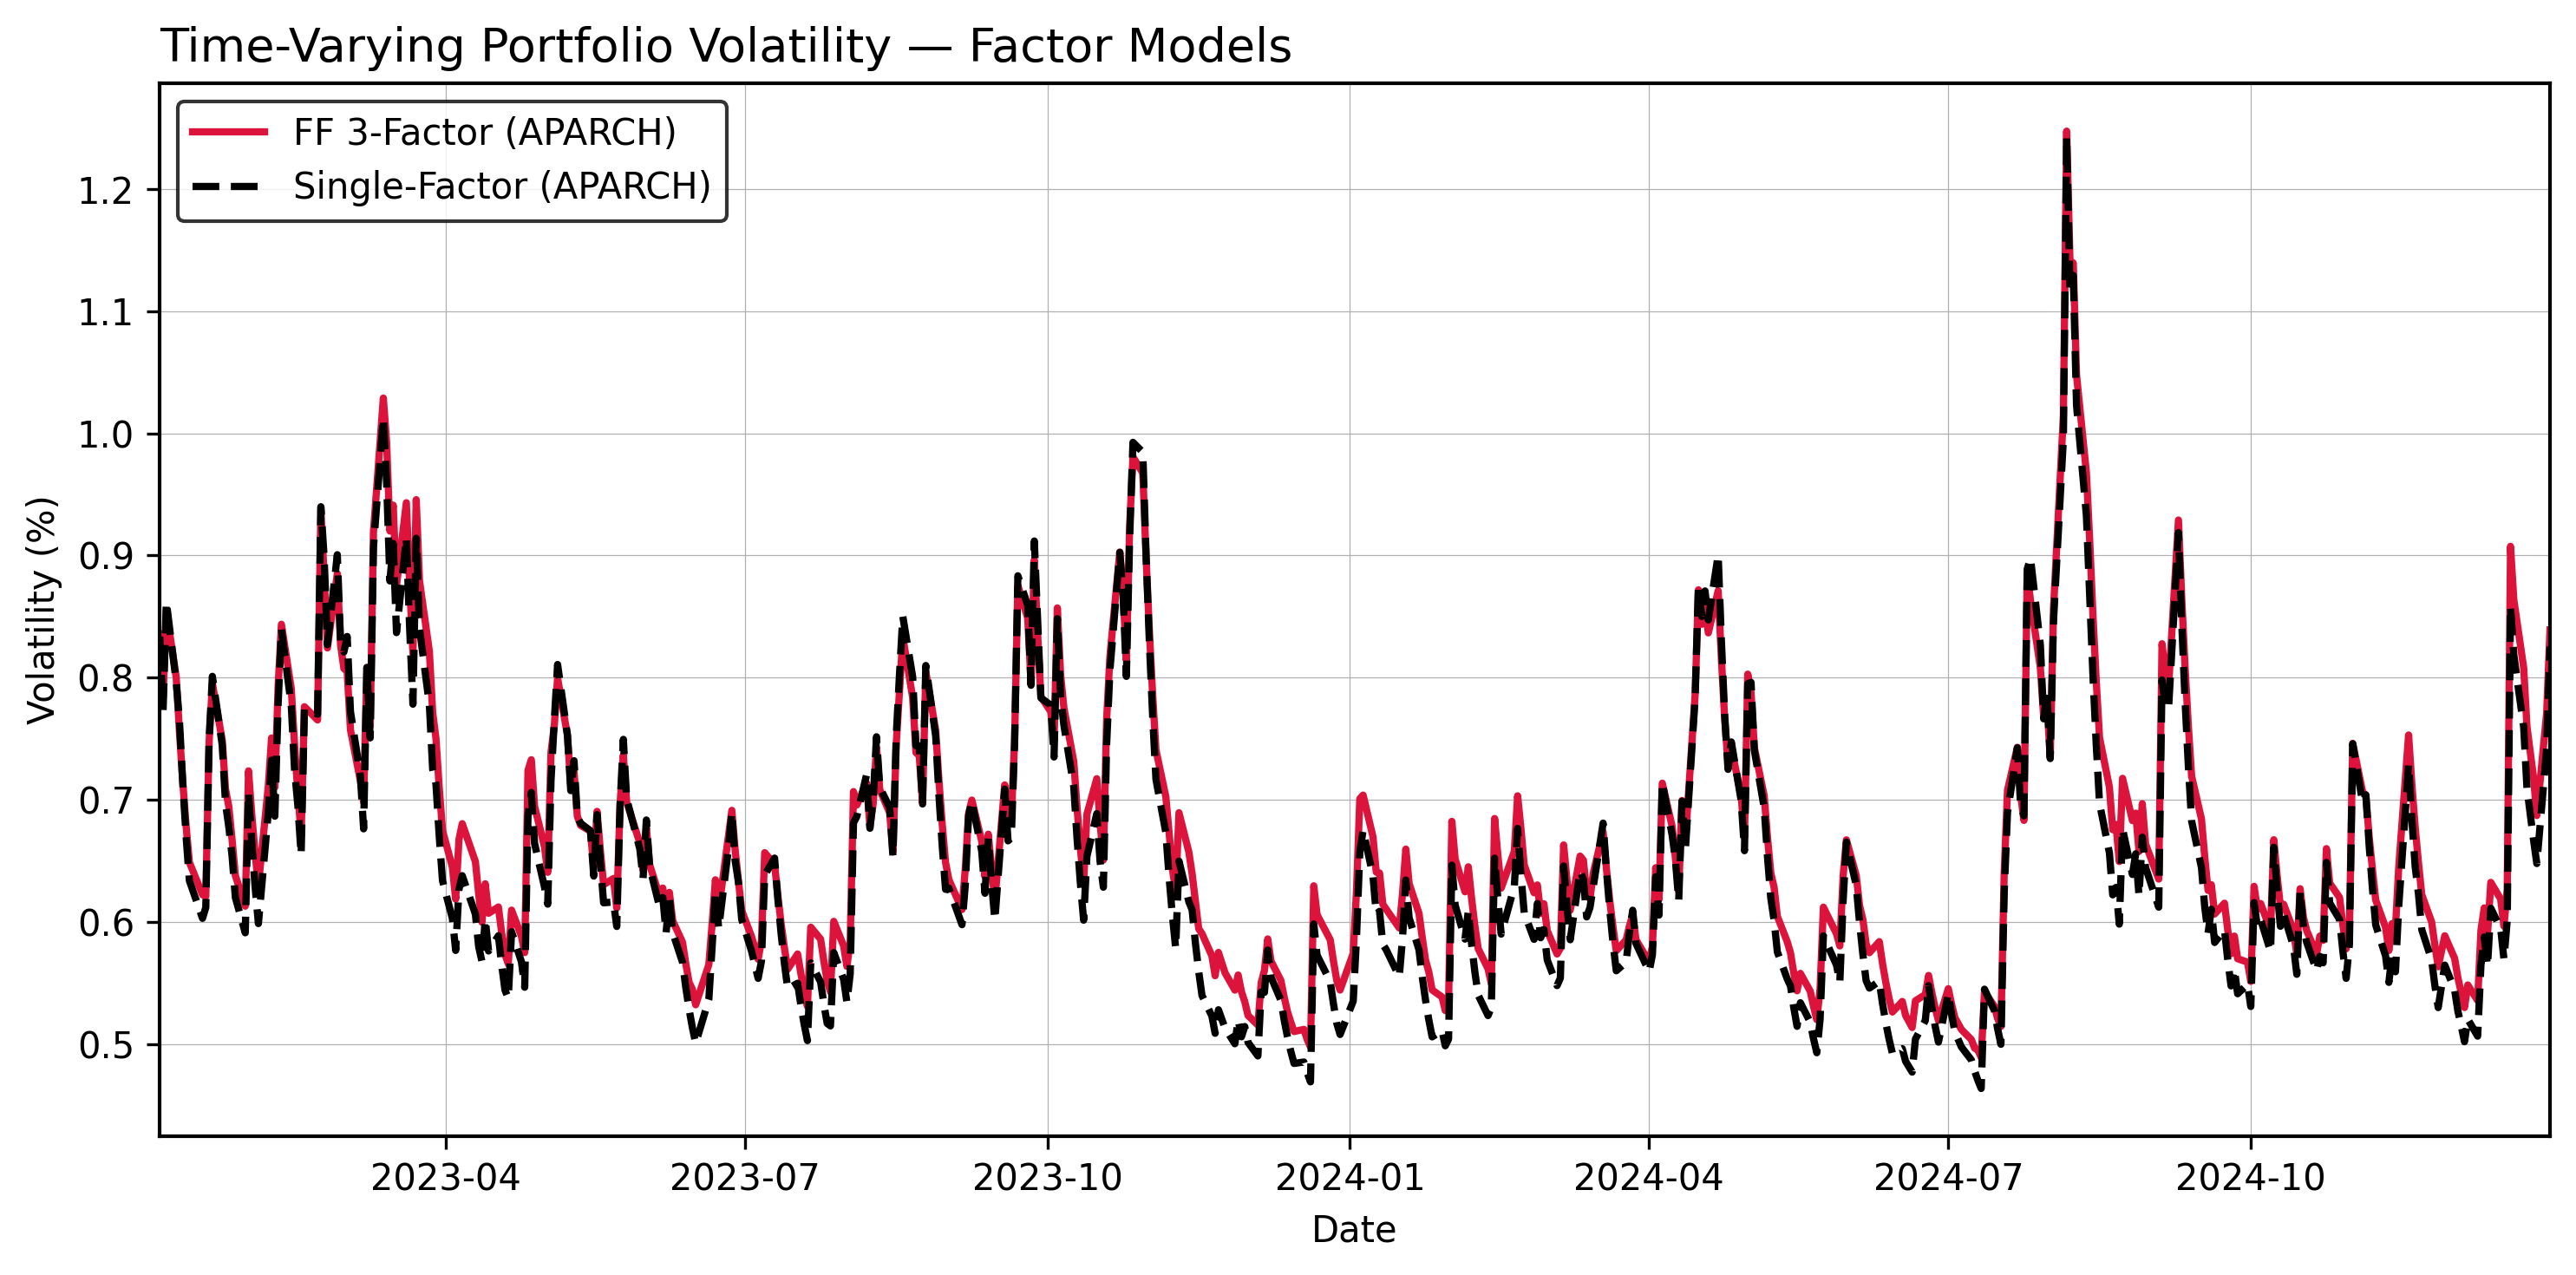

In [65]:
# Create figure
plt.figure(figsize=(10, 5), dpi=300)

# Plot GARCH volatilities with requested style
plt.plot(
    ff3_garch_volatility.index,
    100 * ff3_garch_volatility,
    label="FF 3-Factor (APARCH)",
    color="crimson",
    linewidth=2.0,
    linestyle="-"
)

plt.plot(
    sf_garch_volatility.index,
    100 * sf_garch_volatility,
    label="Single-Factor (APARCH)",
    color="black",
    linewidth=2.0,
    linestyle="--"
)

# Titles and labels
plt.title("Time-Varying Portfolio Volatility — Factor Models", loc="left", fontsize=13, fontweight="medium")
plt.xlabel("Date")
plt.ylabel("Volatility (%)")

# Axis styling
ax = plt.gca()
ax.set_xlim(ff3_garch_volatility.index.min(), ff3_garch_volatility.index.max())  # tighten side borders

for side in ["top", "bottom", "left", "right"]:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_color("black")
    ax.spines[side].set_linewidth(1)

ax.tick_params(width=0.8, color="black")
plt.grid(True, linewidth=0.3)

# Legend without title
plt.legend(frameon=True, edgecolor="black")
plt.tight_layout()
plt.show()